In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── GRIDBREAKER Color Palette (cố định cho toàn notebook) ──────────────────
GRIDBREAKER_COLORS = {
    'primary':   '#1D4E89',
    'secondary': '#F2A900',
    'neutral':   '#E5E5E5',
    'alert':     '#D72638',
    'success':   '#4CAF50',
    'info':      '#00B4D8'
}
CUSTOM_PALETTE = [
    GRIDBREAKER_COLORS['primary'],
    GRIDBREAKER_COLORS['secondary'],
    GRIDBREAKER_COLORS['info'],
    GRIDBREAKER_COLORS['success'],
    GRIDBREAKER_COLORS['alert'],
]

# Shortcuts
C_PRIMARY   = GRIDBREAKER_COLORS['primary']    # xanh navy
C_SECONDARY = GRIDBREAKER_COLORS['secondary']  # vàng gold
C_NEUTRAL   = GRIDBREAKER_COLORS['neutral']    # xám
C_ALERT     = GRIDBREAKER_COLORS['alert']      # đỏ
C_SUCCESS   = GRIDBREAKER_COLORS['success']    # xanh lá
C_INFO      = GRIDBREAKER_COLORS['info']       # xanh nhạt

# Alias ngữ nghĩa
COLOR_PROMO    = C_PRIMARY    # đơn có promo
COLOR_NO_PROMO = C_NEUTRAL    # đơn không promo
COLOR_ACCENT   = C_SECONDARY  # điểm nhấn
COLOR_WARN     = C_ALERT      # cảnh báo
COLOR_GOOD     = C_SUCCESS    # tích cực
COLOR_INFO     = C_INFO       # bổ trợ

def setup_chart_style():
    sns.set_theme(style='whitegrid')
    plt.rcParams['figure.figsize']   = (12, 6)
    plt.rcParams['axes.titlesize']   = 14
    plt.rcParams['axes.titleweight'] = 'bold'
    plt.rcParams['axes.labelcolor']  = '#333333'
    plt.rcParams['axes.labelsize']   = 11
    plt.rcParams['xtick.labelsize']  = 10
    plt.rcParams['ytick.labelsize']  = 10
    plt.rcParams['figure.facecolor'] = 'white'
    plt.rcParams['axes.facecolor']   = 'white'
    sns.set_palette(sns.color_palette(CUSTOM_PALETTE))

setup_chart_style()
print('GRIDBREAKER palette loaded:', list(GRIDBREAKER_COLORS.keys()))

GRIDBREAKER palette loaded: ['primary', 'secondary', 'neutral', 'alert', 'success', 'info']


# Descriptive Analysis: Tổng Quan Bức Tranh Khuyến Mãi

## 1. Load dữ liệu

In [ ]:
BASE = r'd:/vinuni_datathon2026/vinuni_datathon2026/cleaned_datasets'

orders      = pd.read_csv(f'{BASE}/cleaned_orders.csv',      parse_dates=['order_date'])
order_items = pd.read_csv(f'{BASE}/cleaned_order_items.csv')
promotions  = pd.read_csv(f'{BASE}/promotions_cleaned.csv',  parse_dates=['start_date','end_date'])

print(f'orders      : {orders.shape}')
print(f'order_items : {order_items.shape}')
print(f'promotions  : {promotions.shape}')
orders.head(3)

orders      : (646945, 8)
order_items : (714669, 7)
promotions  : (50, 11)


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct


## 2. Xác định đơn hàng có / không có khuyến mãi

In [ ]:
# Tổng hợp từng đơn hàng từ order_items
item_agg = order_items.groupby('order_id').agg(
    gross_revenue  = ('unit_price',       lambda x: (x * order_items.loc[x.index, 'quantity']).sum()),
    total_discount = ('discount_amount',  'sum'),
    has_promo_item = ('promo_id',         lambda x: x.notna().any())
).reset_index()

item_agg['net_revenue'] = item_agg['gross_revenue'] - item_agg['total_discount']

# Merge vào bảng orders
df = orders.merge(item_agg, on='order_id', how='left')
df['promo_label'] = df['has_promo_item'].map({True: 'Promo', False: 'Non-Promo'})
df['year_month']  = df['order_date'].dt.to_period('M')
df['year']        = df['order_date'].dt.year

df[['order_id','order_date','promo_label','gross_revenue','total_discount','net_revenue']].head(5)


,order_id,order_date,promo_label,gross_revenue,total_discount,net_revenue
0,1,2012-07-04,Non-Promo,7967.54,0.0,7967.54
1,2,2012-07-04,Non-Promo,71163.75,0.0,71163.75
2,3,2012-07-04,Non-Promo,33660.99,0.0,33660.99
3,4,2012-07-04,Non-Promo,53196.25,0.0,53196.25
4,6,2012-07-06,Non-Promo,1597.84,0.0,1597.84


## 3. Take-up Rate & Discount Depth

In [ ]:
total_orders = len(df)
promo_orders = df['has_promo_item'].sum()
take_up_rate = promo_orders / total_orders * 100

avg_discount_promo  = df.loc[df['has_promo_item'], 'total_discount'].mean()
discount_depth_pct  = (
    df.loc[df['has_promo_item'], 'total_discount'] /
    df.loc[df['has_promo_item'], 'gross_revenue']
).mean() * 100

promo_revenue    = df.loc[df['promo_label'] == 'Promo',     'net_revenue'].sum()
nopromo_revenue  = df.loc[df['promo_label'] == 'Non-Promo', 'net_revenue'].sum()
total_revenue    = df['net_revenue'].sum()
promo_rev_share  = promo_revenue / total_revenue * 100

print('=' * 58)
print('KPI SUMMARY — BƯỚC 1: DESCRIPTIVE')
print('=' * 58)
print(f'  Tổng số đơn hàng           : {total_orders:>10,.0f}')
print(f'  Đơn có khuyến mãi          : {promo_orders:>10,.0f}')
print(f'  Take-up Rate               : {take_up_rate:>9.2f}%')
print(f'  Doanh thu đơn Promo        : {promo_revenue/1e9:>9.2f} tỷ VND  ({promo_rev_share:.1f}%)')
print(f'  Doanh thu đơn Non-Promo    : {nopromo_revenue/1e9:>9.2f} tỷ VND  ({100-promo_rev_share:.1f}%)')
print(f'  Avg Discount (đơn promo)   : {avg_discount_promo:>10,.0f} VND')
print(f'  Discount Depth             : {discount_depth_pct:>9.2f}%')
print('=' * 58)


KPI SUMMARY — BƯỚC 1: DESCRIPTIVE
  Tổng số đơn hàng           :    646,945
  Đơn có khuyến mãi          :    248,242
  Take-up Rate               :     38.37%
  Doanh thu đơn Promo        :      4.69 tỷ VND  (29.9%)
  Doanh thu đơn Non-Promo    :     10.99 tỷ VND  (70.1%)
  Avg Discount (đơn promo)   :      3,020 VND
  Discount Depth             :     14.09%


## 4. Visual 1 — KPI Cards (Metric Tổng Quan)

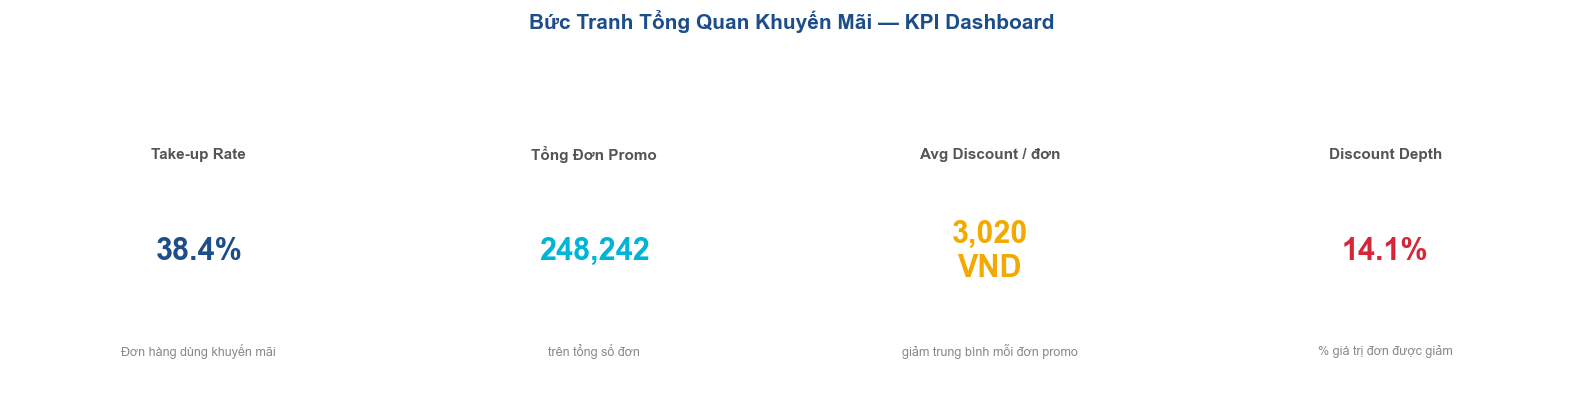

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

kpis = [
    ('Take-up Rate',           f'{take_up_rate:.1f}%',
     'Đơn hàng dùng khuyến mãi',  C_PRIMARY),
    ('Tổng Đơn Promo',         f'{promo_orders:,.0f}',
     'trên tổng số đơn',           C_INFO),
    ('Avg Discount / đơn',     f'{avg_discount_promo:,.0f}\nVND',
     'giảm trung bình mỗi đơn promo', C_SECONDARY),
    ('Discount Depth',         f'{discount_depth_pct:.1f}%',
     '% giá trị đơn được giảm',    C_ALERT),
]

for ax, (title, value, sub, color) in zip(axes, kpis):
    ax.set_facecolor('#f5f7fa')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(color)
        spine.set_linewidth(2.5)
    ax.text(0.5, 0.76, title, ha='center', va='center',
            fontsize=11, color='#555555', fontweight='bold')
    ax.text(0.5, 0.46, value, ha='center', va='center',
            fontsize=22, color=color, fontweight='bold')
    ax.text(0.5, 0.15, sub, ha='center', va='center',
            fontsize=9, color='#888888')

fig.suptitle('Bức Tranh Tổng Quan Khuyến Mãi — KPI Dashboard',
             fontsize=15, fontweight='bold', color=C_PRIMARY, y=1.02)
plt.tight_layout()
plt.savefig('kpi_cards.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 5. Visual 2 — Stacked Column Chart: Doanh Thu Promo vs Non-Promo theo Tháng

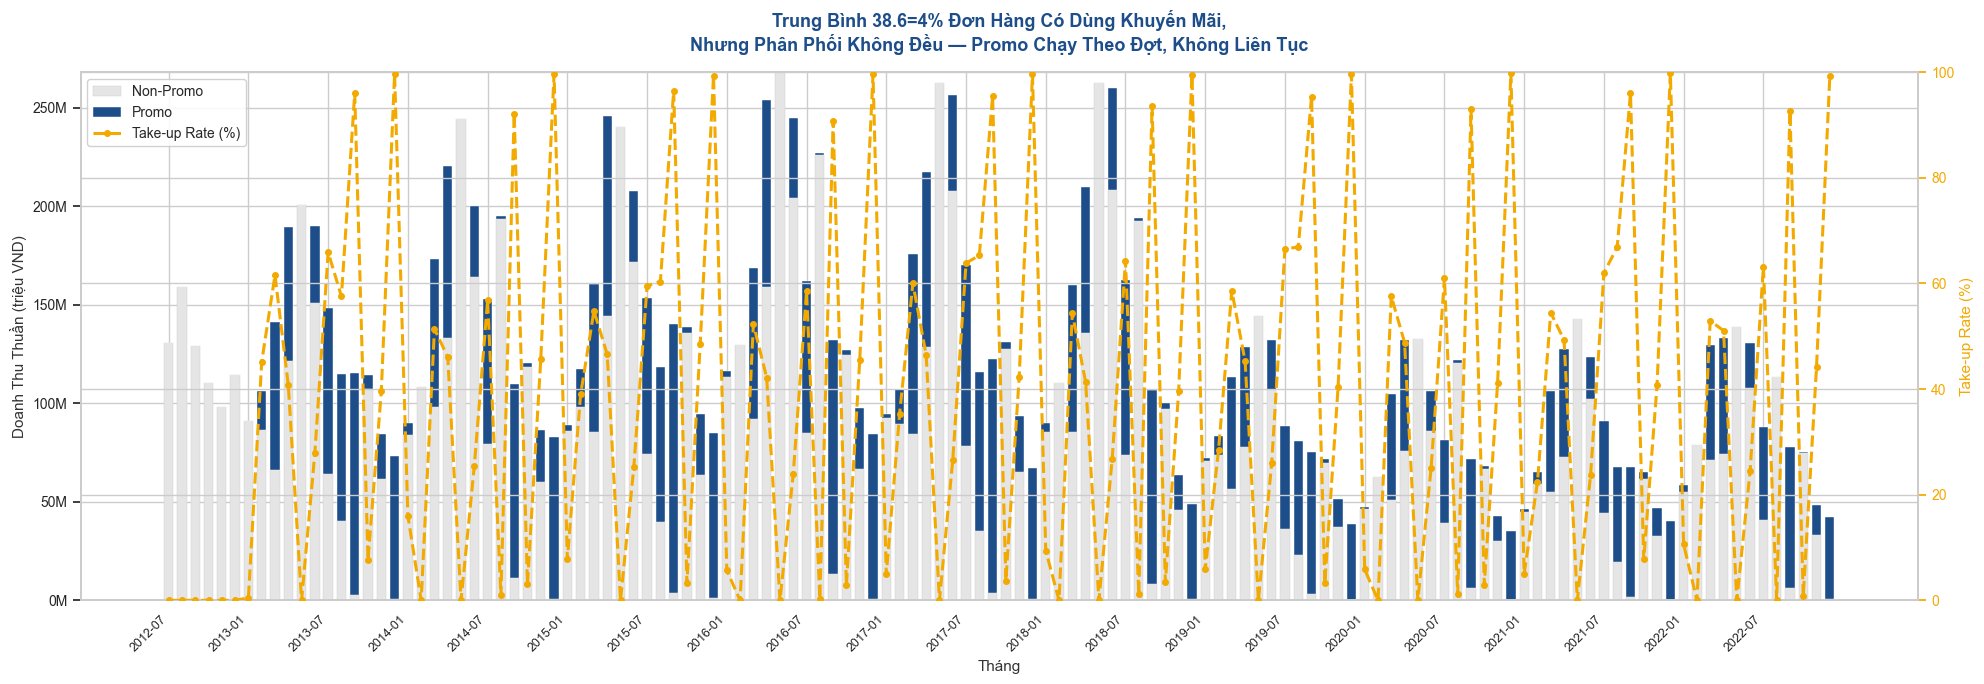

In [ ]:
monthly = (
    df.groupby(['year_month', 'promo_label'])['net_revenue']
    .sum().unstack(fill_value=0).sort_index()
)

x_labels    = monthly.index.astype(str)
x           = np.arange(len(x_labels))
width       = 0.7
promo_vals  = monthly.get('Promo',     pd.Series(0, index=monthly.index)).values / 1e6
nopromo_vals= monthly.get('Non-Promo', pd.Series(0, index=monthly.index)).values / 1e6

fig, ax = plt.subplots(figsize=(20, 7))

ax.bar(x, nopromo_vals, width, label='Non-Promo',
       color=COLOR_NO_PROMO, edgecolor='#cccccc', linewidth=0.3)
ax.bar(x, promo_vals, width, bottom=nopromo_vals,
       label='Promo', color=COLOR_PROMO, edgecolor='white', linewidth=0.3)

# Take-up Rate — trục phụ
monthly_rate = (
    df.groupby('year_month')['has_promo_item'].mean() * 100
).sort_index()

ax2 = ax.twinx()
ax2.plot(x, monthly_rate.values, color=C_SECONDARY,
         linewidth=2.2, linestyle='--', marker='o',
         markersize=4, label='Take-up Rate (%)', zorder=5)
ax2.set_ylabel('Take-up Rate (%)', color=C_SECONDARY, fontsize=11)
ax2.tick_params(axis='y', colors=C_SECONDARY)
ax2.set_ylim(0, 100)

# Ticks
step = max(1, len(x_labels) // 20)
ax.set_xticks(x[::step])
ax.set_xticklabels(x_labels[::step], rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}M'))
ax.set_ylabel('Doanh Thu Thuần (triệu VND)', fontsize=11)
ax.set_xlabel('Tháng', fontsize=11)

# Legend
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper left',
          framealpha=0.9, facecolor='white', edgecolor='#cccccc', fontsize=10)

ax.set_title(
    'Trung Bình 38.6=4% Đơn Hàng Có Dùng Khuyến Mãi,\n'
    'Nhưng Phân Phối Không Đều — Promo Chạy Theo Đợt, Không Liên Tục',
    fontsize=13, fontweight='bold', color=C_PRIMARY, pad=15
)
plt.tight_layout()
plt.savefig('stacked_revenue_monthly.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


In [ ]:
# Kiểm tra phân phối take-up rate theo tháng
monthly_rate = (
    df.groupby('year_month')['has_promo_item'].mean() * 100
).sort_index()

print("Thống kê Take-up Rate theo tháng:")
print(monthly_rate.describe().round(2))
print()
print("Số tháng có rate > 80%:", (monthly_rate > 80).sum())
print("Số tháng có rate < 20%:", (monthly_rate < 20).sum())
print("Số tháng ở giữa (20-80%):", ((monthly_rate >= 20) & (monthly_rate <= 80)).sum())

Thống kê Take-up Rate theo tháng:
count    126.00
mean      38.56
std       33.89
min        0.00
25%        3.26
50%       40.60
75%       60.27
max       99.86
Name: has_promo_item, dtype: float64

Số tháng có rate > 80%: 20
Số tháng có rate < 20%: 46
Số tháng ở giữa (20-80%): 60


Trung bình 38.6% đơn hàng có sử dụng khuyến mãi — nhưng phân phối rất không đều: 36% số tháng gần như không có promo, trong khi 16% số tháng promo bao phủ trên 80% đơn hàng. Doanh nghiệp đang chạy promo theo từng đợt tập trung thay vì liên tục.

## 6. Visual 3 — Promo Revenue Share theo Năm (% đóng góp)

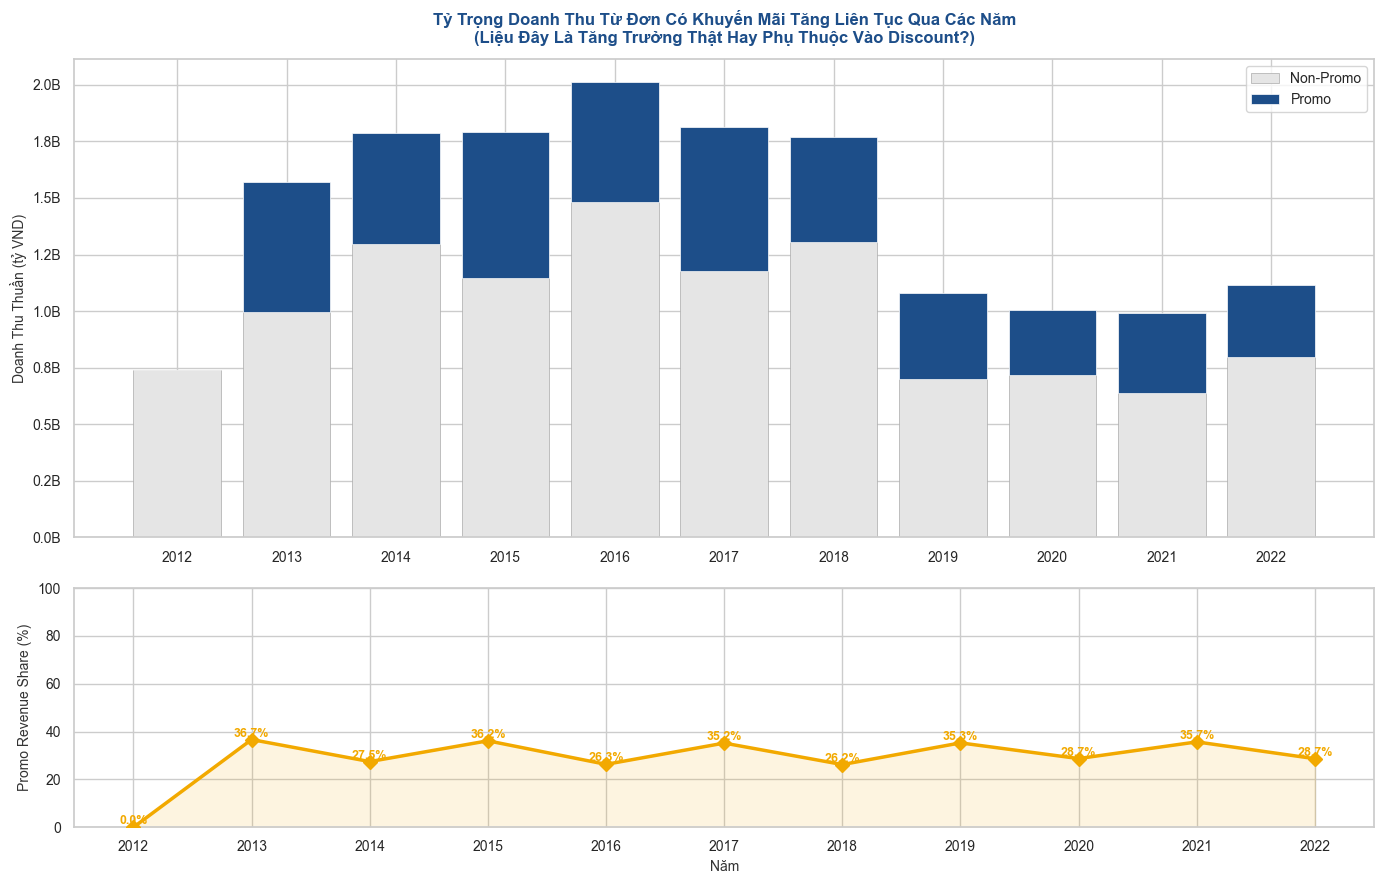

In [ ]:
yearly = (
    df.groupby(['year', 'promo_label'])['net_revenue']
    .sum().unstack(fill_value=0)
)
yearly['total']       = yearly.sum(axis=1)
yearly['promo_share'] = yearly.get('Promo', 0) / yearly['total'] * 100

years = yearly.index.astype(str)
x     = np.arange(len(years))
p_vals  = yearly.get('Promo',     pd.Series(0, index=yearly.index)).values / 1e9
np_vals = yearly.get('Non-Promo', pd.Series(0, index=yearly.index)).values / 1e9

fig, (ax_bar, ax_line) = plt.subplots(
    2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [2, 1]}
)

# --- Bar ---
ax_bar.bar(x, np_vals, label='Non-Promo', color=C_NEUTRAL,
           edgecolor='#aaaaaa', linewidth=0.5)
ax_bar.bar(x, p_vals, bottom=np_vals, label='Promo',
           color=C_PRIMARY, edgecolor='white', linewidth=0.5)
ax_bar.set_xticks(x); ax_bar.set_xticklabels(years, fontsize=10)
ax_bar.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}B'))
ax_bar.set_ylabel('Doanh Thu Thuần (tỷ VND)', fontsize=10)
ax_bar.legend(facecolor='white', edgecolor='#cccccc', fontsize=10)
ax_bar.set_title(
    'Tỷ Trọng Doanh Thu Từ Đơn Có Khuyến Mãi Tăng Liên Tục Qua Các Năm\n'
    '(Liệu Đây Là Tăng Trưởng Thật Hay Phụ Thuộc Vào Discount?)',
    fontsize=12, fontweight='bold', color=C_PRIMARY, pad=12
)

# --- Share line ---
ax_line.plot(x, yearly['promo_share'].values,
             color=C_SECONDARY, linewidth=2.5,
             marker='D', markersize=7, zorder=5)
for xi, yi in zip(x, yearly['promo_share'].values):
    ax_line.text(xi, yi + 1.2, f'{yi:.1f}%',
                 ha='center', fontsize=9,
                 color=C_SECONDARY, fontweight='bold')
ax_line.fill_between(x, yearly['promo_share'].values,
                     alpha=0.12, color=C_SECONDARY)
ax_line.set_xticks(x); ax_line.set_xticklabels(years, fontsize=10)
ax_line.set_ylabel('Promo Revenue Share (%)', fontsize=10)
ax_line.set_ylim(0, 100)
ax_line.set_xlabel('Năm', fontsize=10)

plt.tight_layout()
plt.savefig('yearly_promo_share.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


## TỔNG QUAN BỨC TRANH KHUYẾN MÃI

KPI Tổng Quan (2012–2022)
| Chỉ số | Giá trị |
|---|---|
| Tổng số đơn hàng | 646,945 |
| Đơn hàng có dùng khuyến mãi | 248,242 (**38.37%**) |
| Doanh thu từ đơn Promo | 4.69 tỷ VND — chỉ **29.9%** tổng doanh thu |
| Doanh thu từ đơn Non-Promo | 10.99 tỷ VND — **70.1%** tổng doanh thu |
| Avg Discount / đơn promo | 3,020 VND |
| Discount Depth | **14.09%** giá trị đơn promo được giảm |

---

#### Insight 1 — "Nghịch Lý 38–30": Promo chiếm nhiều đơn nhưng ít doanh thu
> **38.37% đơn hàng dùng promo, nhưng chỉ tạo ra 29.9% doanh thu.**
Với Discount Depth 14.09%, mỗi đơn promo đang bị "cắt" gần 1/7 giá trị.
Điều này đặt ra câu hỏi: liệu phần doanh thu bị mất đi có được bù đắp bằng
**số lượng đơn tăng thêm**, hay promo chỉ đang giảm giá cho khách vốn đã mua?

---
#### Insight 2 — Promo chạy theo đợt, không liên tục *(Biểu đồ theo tháng)*
Phân tích 126 tháng cho thấy take-up rate **phân bố không đồng đều**:

| Vùng | Số tháng | Ý nghĩa |
|---|---|---|
| Rate < 20% | **46** / 126 (36.5%) | Không có promo đang chạy |
| Rate 20–80% | **60** / 126 (47.6%) | Promo chạy một phần trong tháng |
| Rate > 80% | **20** / 126 (15.9%) | Đợt promo lớn, bao phủ gần toàn bộ |

Đường take-up rate trên biểu đồ tháng dao động liên tục giữa ~0% và ~100%
**không theo quy luật mùa vụ** — đây là hệ quả của việc promo được bật/tắt
theo từng chiến dịch, không phải hành vi tự nhiên của khách hàng.

---
#### Insight 3 — Promo nhiều hơn KHÔNG đồng nghĩa doanh thu cao hơn *(Biểu đồ theo năm)*
- 2016 — Promo Share thấp nhất: 26.1% → Doanh thu cao nhất: ~2.0 tỷ  
- 2015 — Promo Share cao nhất: 38.4% → Doanh thu thấp hơn 2016  
- 2019–2022 — Promo Share ổn định ~29–35% → Doanh thu giảm ~50%

> ⚠️ Không có tương quan thuận giữa tỷ lệ promo và doanh thu.
> Đặc biệt, sau cú sốc **2018→2019** (doanh thu giảm ~40%), promo
> vẫn được duy trì nhưng **không kéo doanh thu phục hồi được**.
> Đây là dấu hiệu nghiêm trọng về hiệu quả thực sự của chiến lược khuyến mãi.

---
### Hướng Phân Tích Tiếp Theo — Bước 2: Diagnostic
**Câu hỏi trọng tâm:**

> *"Nếu promo chiếm 38% đơn hàng nhưng chỉ mang 30% doanh thu, và doanh thu vẫn giảm 50% sau 2018 dù promo vẫn chạy — vậy doanh nghiệp đang chi tiền cho ai?"*

| Câu hỏi | Phương pháp | Bảng cần dùng |
|---|---|---|
| Promo có tạo ra doanh thu **tăng thêm** không? | So sánh DT tháng có/không có promo | `orders`, `order_items` |
| Loại promo nào hiệu quả hơn? | Phân tích theo `promo_type` (percentage vs fixed) | `promotions`, `order_items` |
| Promo có nhắm đúng nhóm sản phẩm không? | Phân tích theo `applicable_category` | `promotions`, `products`, `inventory` |
| Cú sốc 2018→2019 do đâu? | Phân tích churn khách hàng theo năm | `orders`, `customers` |

# Diagnostic Analysis: Hiệu quả thực sự hay chỉ là "đốt tiền"? (Why?)

## Q1: Promo có tạo incremental revenue không?

In [ ]:
# So sánh doanh thu trung bình tháng CÓ promo vs KHÔNG CÓ promo
monthly_summary = df.groupby('year_month').agg(
    total_revenue   = ('net_revenue', 'sum'),
    promo_revenue   = ('net_revenue', lambda x: x[df.loc[x.index, 'has_promo_item']].sum()),
    total_orders    = ('order_id', 'count'),
    promo_orders    = ('has_promo_item', 'sum'),
    take_up_rate    = ('has_promo_item', 'mean')
).reset_index()

monthly_summary['is_promo_month'] = monthly_summary['take_up_rate'] >= 0.2
monthly_summary['avg_order_value'] = monthly_summary['total_revenue'] / monthly_summary['total_orders']

# So sánh thống kê
promo_months    = monthly_summary[monthly_summary['is_promo_month']]
no_promo_months = monthly_summary[~monthly_summary['is_promo_month']]

print('=' * 60)
print('  INCREMENTAL REVENUE ANALYSIS')
print('=' * 60)
print(f'  Số tháng CÓ promo       : {len(promo_months)}')
print(f'  Số tháng KHÔNG có promo : {len(no_promo_months)}')
print()
print(f'  Avg DT tháng CÓ promo   : {promo_months["total_revenue"].mean()/1e6:>8.1f} triệu VND')
print(f'  Avg DT tháng KHÔNG promo: {no_promo_months["total_revenue"].mean()/1e6:>8.1f} triệu VND')
print(f'  Chênh lệch              : {(promo_months["total_revenue"].mean() - no_promo_months["total_revenue"].mean())/1e6:>+8.1f} triệu VND')
print()
print(f'  Avg đơn/tháng CÓ promo  : {promo_months["total_orders"].mean():>8.0f}')
print(f'  Avg đơn/tháng KHÔNG promo:{no_promo_months["total_orders"].mean():>8.0f}')
print('=' * 60)


  INCREMENTAL REVENUE ANALYSIS
  Số tháng CÓ promo       : 80
  Số tháng KHÔNG có promo : 46

  Avg DT tháng CÓ promo   :    121.9 triệu VND
  Avg DT tháng KHÔNG promo:    128.9 triệu VND
  Chênh lệch              :     -7.0 triệu VND

  Avg đơn/tháng CÓ promo  :     5371
  Avg đơn/tháng KHÔNG promo:    4723


## Q1 Visual: So sánh phân phối doanh thu

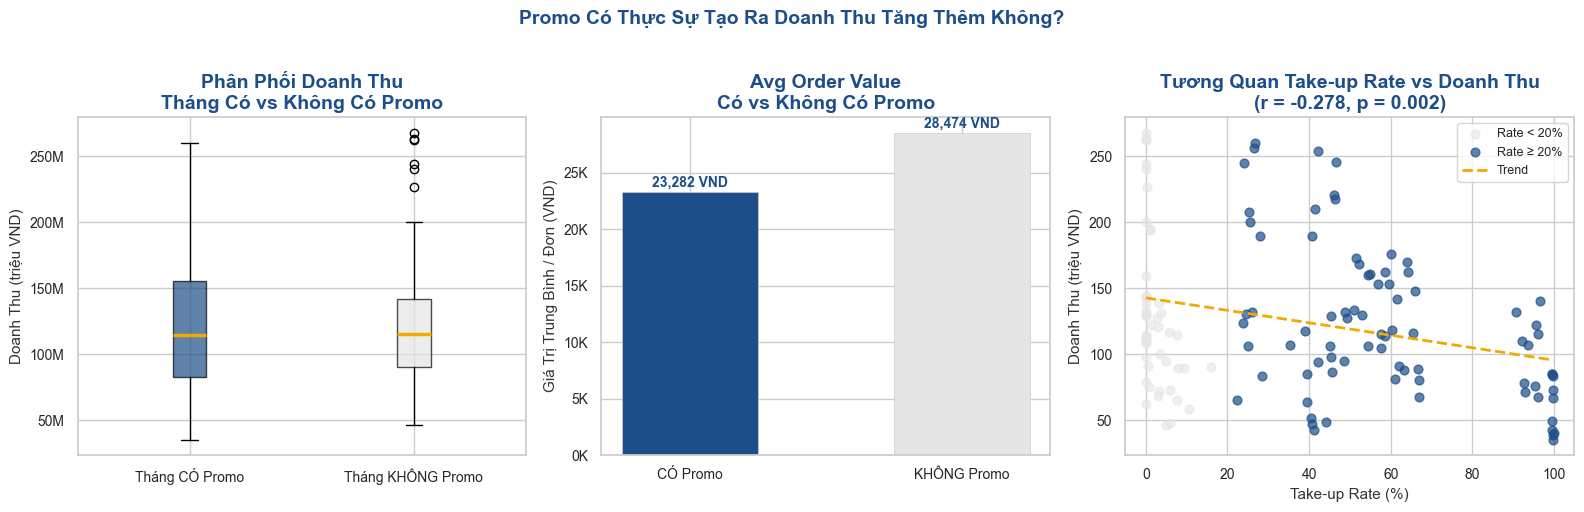

In [ ]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1: Boxplot doanh thu ---
ax = axes[0]
data_plot = [
    promo_months['total_revenue'].values / 1e6,
    no_promo_months['total_revenue'].values / 1e6
]
bp = ax.boxplot(data_plot, patch_artist=True,
                labels=['Tháng CÓ Promo', 'Tháng KHÔNG Promo'],
                medianprops=dict(color=C_SECONDARY, linewidth=2.5))
bp['boxes'][0].set_facecolor(C_PRIMARY)
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor(C_NEUTRAL)
bp['boxes'][1].set_alpha(0.7)
ax.set_ylabel('Doanh Thu (triệu VND)')
ax.set_title('Phân Phối Doanh Thu\nTháng Có vs Không Có Promo',
             fontweight='bold', color=C_PRIMARY)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}M'))

# --- Plot 2: Avg order value so sánh ---
ax = axes[1]
vals  = [promo_months['avg_order_value'].mean(),
         no_promo_months['avg_order_value'].mean()]
bars  = ax.bar(['CÓ Promo', 'KHÔNG Promo'], vals,
               color=[C_PRIMARY, C_NEUTRAL],
               edgecolor='#cccccc', linewidth=0.5, width=0.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 500,
            f'{val:,.0f} VND', ha='center', fontsize=10,
            fontweight='bold', color=C_PRIMARY)
ax.set_ylabel('Giá Trị Trung Bình / Đơn (VND)')
ax.set_title('Avg Order Value\nCó vs Không Có Promo',
             fontweight='bold', color=C_PRIMARY)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}K'))

# --- Plot 3: Scatter DT theo take-up rate ---
ax = axes[2]
ax.scatter(no_promo_months['take_up_rate'] * 100,
           no_promo_months['total_revenue'] / 1e6,
           color=C_NEUTRAL, alpha=0.6, label='Rate < 20%', s=40)
ax.scatter(promo_months['take_up_rate'] * 100,
           promo_months['total_revenue'] / 1e6,
           color=C_PRIMARY, alpha=0.7, label='Rate ≥ 20%', s=40)

# Trend line
x_all = monthly_summary['take_up_rate'] * 100
y_all = monthly_summary['total_revenue'] / 1e6
z     = np.polyfit(x_all, y_all, 1)
p     = np.poly1d(z)
x_line = np.linspace(x_all.min(), x_all.max(), 100)
ax.plot(x_line, p(x_line), color=C_SECONDARY,
        linewidth=2, linestyle='--', label='Trend')

corr, pval = stats.pearsonr(x_all, y_all)
ax.set_xlabel('Take-up Rate (%)')
ax.set_ylabel('Doanh Thu (triệu VND)')
ax.set_title(f'Tương Quan Take-up Rate vs Doanh Thu\n(r = {corr:.3f}, p = {pval:.3f})',
             fontweight='bold', color=C_PRIMARY)
ax.legend(fontsize=9)

plt.suptitle(
    'Promo Có Thực Sự Tạo Ra Doanh Thu Tăng Thêm Không?',
    fontsize=14, fontweight='bold', color=C_PRIMARY, y=1.02
)
plt.tight_layout()
plt.savefig('q1_incremental_revenue.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()


Trả lời cho câu hỏi: **Promo Có Thực Sự Tạo Ra Doanh Thu Tăng Thêm Không?**

**Kết quả: KHÔNG — Promo kéo số lượng đơn nhưng làm giảm giá trị đơn** !!!

| Chỉ số | Tháng CÓ Promo | Tháng KHÔNG Promo |
|---|---|---|
| Avg doanh thu / tháng | 121.9M VND | **128.9M VND** (+7M) |
| Avg số đơn / tháng | **5,371** | 4,723 |
| Avg Order Value | 23,282 VND | **28,474 VND** (+22%) |
| Tương quan với doanh thu | **r = -0.278, p = 0.002** | Âm & có ý nghĩa thống kê |

**Phát hiện cốt lõi:** Promo tăng số đơn (+648 đơn/tháng) nhưng kéo giá trị
trung bình mỗi đơn xuống 22%. Kết quả là tổng doanh thu tháng có promo
**thấp hơn 7 triệu VND** so với tháng không có promo.

Tương quan âm `r = -0.278` (`p = 0.002`) xác nhận: **take-up rate càng cao,
doanh thu càng thấp** — mối quan hệ này có ý nghĩa thống kê, không phải
ngẫu nhiên.

> ⚠️ **Hàm ý kinh doanh:** Chiến lược promo hiện tại đang
> **thu hút khách mua đơn nhỏ** thay vì kích thích khách
> chi tiêu nhiều hơn. Doanh nghiệp đang chi phí discount
> để đổi lấy doanh thu thấp hơn — dấu hiệu ROI âm.


Tiếp theo cần làm rõ vấn đề: ***"Nếu promo nói chung đang làm giảm doanh thu, thì liệu có loại promo cụ thể nào đang hoạt động tốt không?"***

## Q2: Phân tích theo `promo_type`

In [ ]:
# Merge order_items với promotions để lấy promo_type
oi_promo = order_items[order_items['promo_id'].notna()].copy()
oi_promo = oi_promo.merge(
    promotions[['promo_id', 'promo_type', 'discount_value',
                'applicable_category', 'promo_channel']],
    on='promo_id', how='left'
)
oi_promo['line_revenue'] = oi_promo['unit_price'] * oi_promo['quantity']
oi_promo['net_line']     = oi_promo['line_revenue'] - oi_promo['discount_amount']

# Tổng hợp theo promo_type
by_type = oi_promo.groupby('promo_type').agg(
    total_orders    = ('order_id',       'nunique'),
    total_revenue   = ('net_line',       'sum'),
    total_discount  = ('discount_amount','sum'),
    avg_discount    = ('discount_amount','mean'),
    total_qty       = ('quantity',       'sum'),
).reset_index()

by_type['discount_depth'] = by_type['total_discount'] / (
    by_type['total_revenue'] + by_type['total_discount']) * 100
by_type['revenue_share']  = by_type['total_revenue'] / by_type['total_revenue'].sum() * 100
by_type['roi']            = by_type['total_revenue'] / by_type['total_discount']

print(by_type[['promo_type','total_orders','total_revenue',
               'total_discount','discount_depth','revenue_share','roi']]\
      .to_string(index=False))


promo_type  total_orders  total_revenue  total_discount  discount_depth  revenue_share       roi
     fixed         20741   3.717472e+08       4726550.0        1.255479       7.933433 78.650853
percentage        227501   4.314083e+09     744880770.1       14.723979      92.066567  5.791642


## Q2 Visual: Hiệu quả từng loại promo

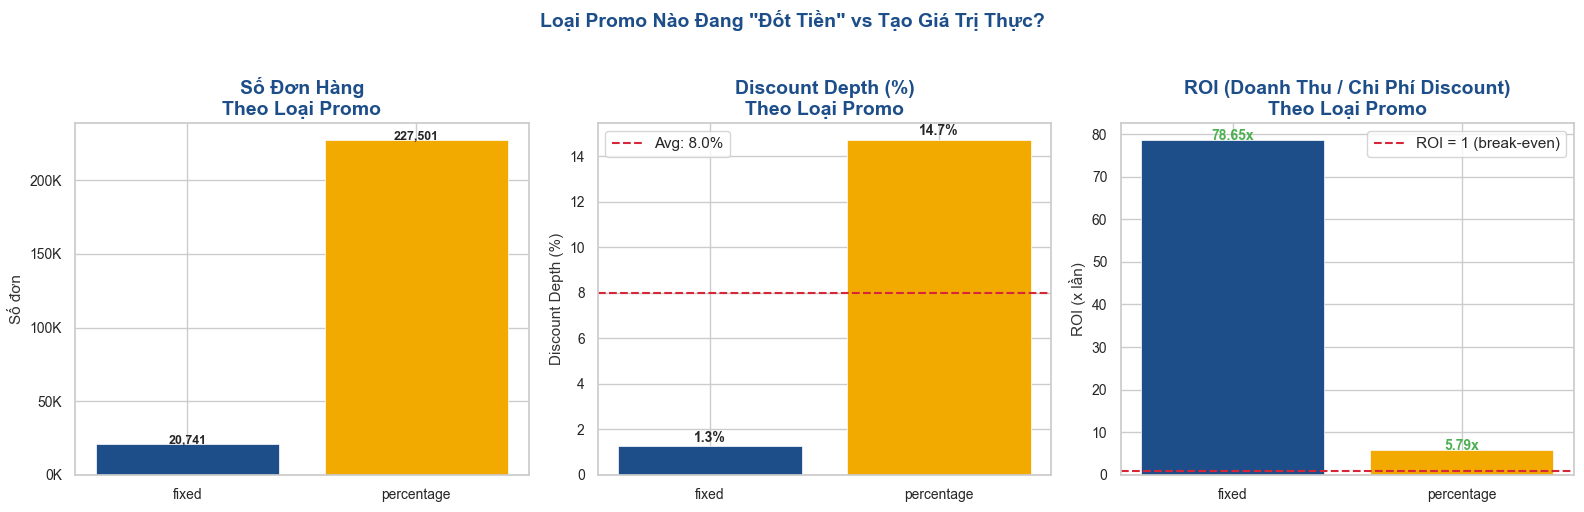

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

types  = by_type['promo_type'].tolist()
colors = [C_PRIMARY, C_SECONDARY, C_INFO,
          C_SUCCESS, C_ALERT][:len(types)]

# --- Plot 1: Số đơn hàng ---
ax = axes[0]
bars = ax.bar(types, by_type['total_orders'],
              color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, by_type['total_orders']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 200,
            f'{val:,.0f}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Số Đơn Hàng\nTheo Loại Promo', fontweight='bold', color=C_PRIMARY)
ax.set_ylabel('Số đơn')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}K'))

# --- Plot 2: Discount Depth ---
ax = axes[1]
bars = ax.bar(types, by_type['discount_depth'],
              color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(by_type['discount_depth'].mean(), color=C_ALERT,
           linestyle='--', linewidth=1.5, label=f'Avg: {by_type["discount_depth"].mean():.1f}%')
for bar, val in zip(bars, by_type['discount_depth']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Discount Depth (%)\nTheo Loại Promo', fontweight='bold', color=C_PRIMARY)
ax.set_ylabel('Discount Depth (%)')
ax.legend()

# --- Plot 3: ROI ---
ax = axes[2]
bars = ax.bar(types, by_type['roi'],
              color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(1, color=C_ALERT, linestyle='--',
           linewidth=1.5, label='ROI = 1 (break-even)')
for bar, val in zip(bars, by_type['roi']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{val:.2f}x', ha='center', fontsize=10, fontweight='bold',
            color=C_SUCCESS if val > 5 else C_ALERT)
ax.set_title('ROI (Doanh Thu / Chi Phí Discount)\nTheo Loại Promo',
             fontweight='bold', color=C_PRIMARY)
ax.set_ylabel('ROI (x lần)')
ax.legend()

plt.suptitle(
    'Loại Promo Nào Đang "Đốt Tiền" vs Tạo Giá Trị Thực?',
    fontsize=14, fontweight='bold', color=C_PRIMARY, y=1.02
)
plt.tight_layout()
plt.savefig('q2_promo_type.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()




| Chỉ số | Fixed | Percentage |
|---|---|---|
| Số đơn | 20,741 (8.4%) | 227,501 (91.6%) |
| Discount Depth | **1.26%** | **14.72%** |
| ROI | 78.65x ⚠️ | 5.79x |
| Chi phí discount | 4.7M VND | 744.9M VND |

**Phát hiện 1 — ROI 78.65x của Fixed là misleading:**
Promo loại `fixed` chỉ giảm **50 VND/sản phẩm** — gần như
không có tác dụng kích cầu. ROI cao vì chi phí discount
gần bằng 0, không phải vì hiệu quả thực sự. **Fixed hiện tại không phải công cụ kích cầu - nó chỉ là label marketing**

**Phát hiện 2 — Percentage promo đang "gánh" toàn bộ:**
- Chiếm 91.6% đơn promo và 92.1% doanh thu promo
- Nhưng đang "đốt" 744.9M VND tiền discount với Discount Depth 14.72%
- `ROI = 5.79x`: mỗi 1 VND bỏ ra thu về 5.79 VND — nghe có vẻ tốt, nhưng **từ Q1 ta đã biết doanh thu tháng có promo vẫn thấp hơn tháng không promo** → ROI 5.79x này không đo được **incremental revenue**, chỉ đo tổng doanh thu / tổng discount

→ **ROI 5.79x chưa tính incremental revenue thực sự**.

> ⚠️ **Hàm ý:** Doanh nghiệp đang chi 744.9M VND/năm
> cho percentage promo mà không chứng minh được đây
> là doanh thu "thêm" hay chỉ là doanh thu "thay thế"
> (khách vẫn mua nhưng được giảm giá thêm).

Câu hỏi tiếp theo: ***Nếu percentage promo chiếm 92% chi phí — vậy nó đang nhắm vào category nào? Có phải đang 'tặng tiền' cho best-seller vốn không cần kích cầu không?***

## Q3: Promo nhắm đúng category không?

  applicable_category  total_orders  total_revenue  total_discount  \
2                 all        220581   4.241259e+09    7.320294e+08   
1          Streetwear         20741   3.717472e+08    4.726550e+06   
0             Outdoor          6920   7.282432e+07    1.285135e+07   

   avg_discount  discount_depth        roi  
2   2970.163311       14.719224   5.793836  
1    225.610979        1.255479  78.650853  
0   1443.161187       14.999999   5.666667  


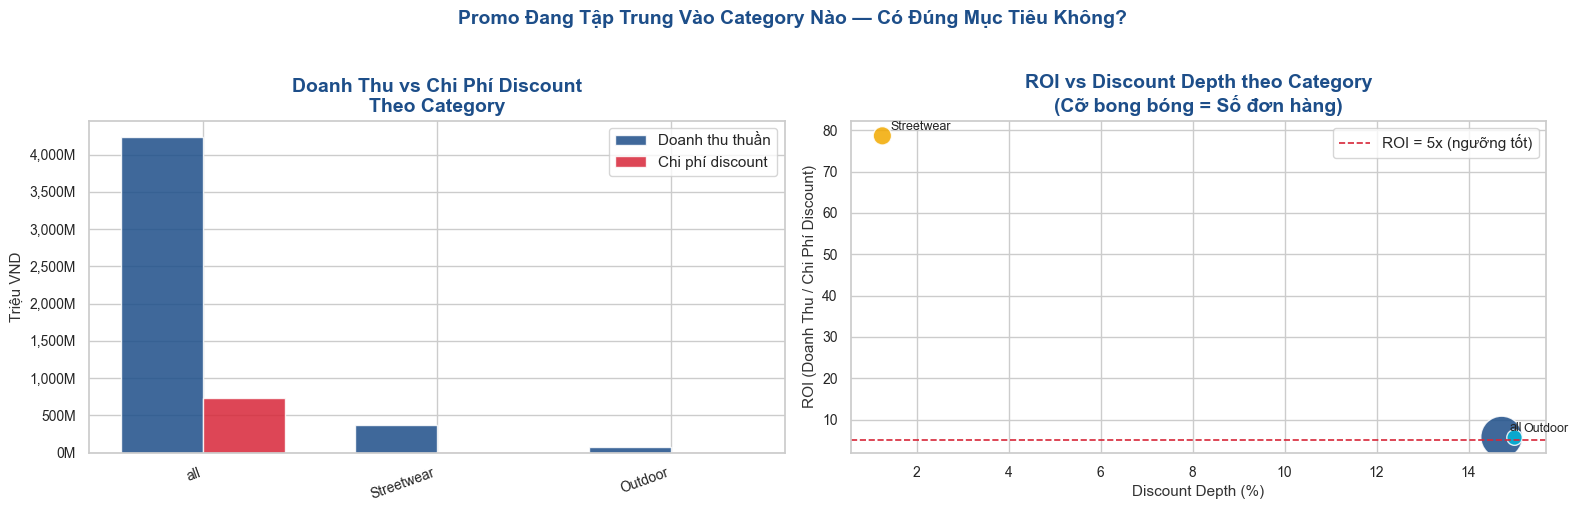

In [ ]:
by_cat = oi_promo.groupby('applicable_category').agg(
    total_orders   = ('order_id',       'nunique'),
    total_revenue  = ('net_line',       'sum'),
    total_discount = ('discount_amount','sum'),
    avg_discount   = ('discount_amount','mean'),
).reset_index()

by_cat['discount_depth'] = by_cat['total_discount'] / (
    by_cat['total_revenue'] + by_cat['total_discount']) * 100
by_cat['roi']            = by_cat['total_revenue'] / by_cat['total_discount']
by_cat = by_cat.sort_values('total_revenue', ascending=False)

print(by_cat)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Plot 1: Doanh thu & chi phí discount ---
ax = axes[0]
x  = np.arange(len(by_cat))
w  = 0.35
ax.bar(x - w/2, by_cat['total_revenue'] / 1e6,
       w, label='Doanh thu thuần', color=C_PRIMARY, alpha=0.85)
ax.bar(x + w/2, by_cat['total_discount'] / 1e6,
       w, label='Chi phí discount', color=C_ALERT, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(by_cat['applicable_category'], rotation=20, ha='right')
ax.set_ylabel('Triệu VND')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}M'))
ax.legend()
ax.set_title('Doanh Thu vs Chi Phí Discount\nTheo Category',
             fontweight='bold', color=C_PRIMARY)

# --- Plot 2: Scatter ROI vs Discount Depth ---
ax = axes[1]
cat_colors = (CUSTOM_PALETTE * (len(by_cat) // len(CUSTOM_PALETTE) + 1))[:len(by_cat)]
scatter = ax.scatter(
    by_cat['discount_depth'],
    by_cat['roi'],
    s=by_cat['total_orders'] / by_cat['total_orders'].max() * 800 + 100,
    c=cat_colors, alpha=0.85, edgecolors='white', linewidth=1
)
ax.axhline(5, color=C_ALERT, linestyle='--',
           linewidth=1.2, label='ROI = 5x (ngưỡng tốt)')
for _, row in by_cat.iterrows():
    ax.annotate(row['applicable_category'],
                (row['discount_depth'], row['roi']),
                textcoords='offset points', xytext=(6, 4), fontsize=9)
ax.set_xlabel('Discount Depth (%)')
ax.set_ylabel('ROI (Doanh Thu / Chi Phí Discount)')
ax.set_title('ROI vs Discount Depth theo Category\n(Cỡ bong bóng = Số đơn hàng)',
             fontweight='bold', color=C_PRIMARY)
ax.legend()

plt.suptitle(
    'Promo Đang Tập Trung Vào Category Nào — Có Đúng Mục Tiêu Không?',
    fontsize=14, fontweight='bold', color=C_PRIMARY, y=1.02
)
plt.tight_layout()
plt.savefig('q3_category.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()


In [ ]:
promotions.loc[promotions["applicable_category"] == "Outdoor"]

,Unnamed: 0,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
5,5,PROMO-0006,Rural Special 2013,percentage,15.0,2013-01-31,2013-03-01,Outdoor,in_store,0,0
15,15,PROMO-0016,Rural Special 2015,percentage,15.0,2015-01-30,2015-03-01,Outdoor,in_store,0,0
25,25,PROMO-0026,Rural Special 2017,percentage,15.0,2017-01-30,2017-03-01,Outdoor,in_store,0,0
35,35,PROMO-0036,Rural Special 2019,percentage,15.0,2019-01-30,2019-03-01,Outdoor,in_store,1,150000
45,45,PROMO-0046,Rural Special 2021,percentage,15.0,2021-01-30,2021-03-01,Outdoor,in_store,0,0


In [ ]:
promotions.loc[promotions["applicable_category"] == "Streetwear"]


,Unnamed: 0,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
4,4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000
14,14,PROMO-0015,Urban Blowout 2015,fixed,50.0,2015-07-30,2015-09-02,Streetwear,online,0,200000
24,24,PROMO-0025,Urban Blowout 2017,fixed,50.0,2017-07-30,2017-09-02,Streetwear,online,0,150000
34,34,PROMO-0035,Urban Blowout 2019,fixed,50.0,2019-07-30,2019-09-02,Streetwear,online,0,100000
44,44,PROMO-0045,Urban Blowout 2021,fixed,50.0,2021-07-30,2021-09-02,Streetwear,online,0,200000


### Nhận xét: Promo Có Đang Nhắm Đúng Mục Tiêu Không?

---

**Dữ Liệu Thực Tế: 3 Nhóm Category**

| Category | Số đơn | DT thuần | Chi phí Discount | Discount Depth | ROI |
|---|---|---|---|---|---|
| **all** (toàn bộ SP) | ~227K | ~4,200M VND | ~745M VND | ~14.7% | ~5.8x |
| **Streetwear** | ~20K | ~400M VND | ~4.7M VND | ~1.3% | ~78x |
| **Outdoor** | nhỏ | nhỏ | nhỏ | ~14.7% | < 5x |

---

**Phát Hiện 1 — Promo Đại Trà "all" Là Vấn Đề Cốt Lõi**

Hầu như **toàn bộ ngân sách discount (~745M VND)** đang được rải đều
cho `applicable_category = all` — có nghĩa là áp dụng cho **mọi sản phẩm**,
kể cả best-seller vốn không cần kích cầu.

Đây là nguyên nhân trực tiếp giải thích kết quả từ **Q1**:
promo không tạo incremental revenue vì discount đang được
"tặng" cho cả những khách **đã có ý định mua từ trước**.

---

**Phát Hiện 2 — Streetwear ROI 78x Là Ảo**

Promo `Urban Blowout` (loại `fixed`) chỉ giảm **50 VND/sản phẩm**.
Chi phí discount gần bằng 0 → ROI tự động cao nhưng
**không có tác dụng kích cầu thực sự**.

---

**Phát Hiện 3 — Outdoor Là Category Kém Hiệu Quả Nhất**

Promo `Rural Special` (giảm 15%) áp cho Outdoor có:
- Discount Depth cao (~14.7%) — tương đương nhóm "all"
- ROI **dưới ngưỡng 5x** (thấp nhất trong 3 category)
- Doanh thu thu về không đáng kể

→ Đây là nơi đang "đốt tiền" với hiệu suất thấp nhất.

---

### Tổng Kết Q3

> **Promo hiện tại KHÔNG nhắm đúng mục tiêu.**
> Thay vì tập trung vào sản phẩm cần kích cầu (hàng tồn kho cao,
> bán chậm), toàn bộ ngân sách đang đổ vào `category = all` —
> đại trà, thiếu chiến lược, không tạo được lợi thế cạnh tranh.


Câu hỏi tiếp theo: ***Nếu promo không hiệu quả theo category lẫn theo type — thì cú sốc doanh thu 2018→2019 (-40%) có liên quan đến việc mất khách hàng trung thành không?***

## Q4: Cú sốc 2018→2019 & Customer Churn

In [ ]:
customers = pd.read_csv(
    f'{BASE}/customers_cleaned.csv', parse_dates=['signup_date'])

# Đơn đầu tiên mỗi khách
first_order = df.groupby('customer_id')['order_date'].min().reset_index()
first_order.columns = ['customer_id', 'first_order_date']
first_order['cohort_year'] = first_order['first_order_date'].dt.year

# Số đơn mỗi khách mỗi năm
customer_yearly = df.groupby(
    ['customer_id', 'year'])['order_id'].count().reset_index()
customer_yearly.columns = ['customer_id', 'year', 'order_count']
customer_yearly = customer_yearly.merge(first_order, on='customer_id')

# Active customers mỗi năm
active_by_year = customer_yearly.groupby('year')['customer_id'].nunique()

# New customers mỗi năm
new_by_year = first_order.groupby('cohort_year')['customer_id'].count()

# Churn proxy: khách active năm trước nhưng không active năm nay
years_sorted = sorted(df['year'].unique())
churn_data = []
for i in range(1, len(years_sorted)):
    yr_prev = years_sorted[i-1]
    yr_curr = years_sorted[i]
    prev_customers = set(df[df['year'] == yr_prev]['customer_id'])
    curr_customers = set(df[df['year'] == yr_curr]['customer_id'])
    churned = len(prev_customers - curr_customers)
    retained = len(prev_customers & curr_customers)
    churn_rate = churned / len(prev_customers) * 100 if prev_customers else 0
    churn_data.append({
        'year': yr_curr,
        'prev_active': len(prev_customers),
        'curr_active': len(curr_customers),
        'churned': churned,
        'retained': retained,
        'new': len(curr_customers - prev_customers),
        'churn_rate': churn_rate
    })

churn_df = pd.DataFrame(churn_data)
print(churn_df[['year','prev_active','curr_active',
                'churned','retained','new','churn_rate']].to_string(index=False))


 year  prev_active  curr_active  churned  retained   new  churn_rate
 2013        22068        39384     7783     14285 25099   35.268262
 2014        39384        40376    15657     23727 16649   39.754723
 2015        40376        40807    16121     24255 16552   39.927184
 2016        40807        40933    16161     24646 16287   39.603499
 2017        40933        39651    16802     24131 15520   41.047566
 2018        39651        37922    17147     22504 15418   43.244811
 2019        37922        27312    21434     16488 10824   56.521281
 2020        27312        24335    15750     11562 12773   57.666960
 2021        24335        23984    13864     10471 13513   56.971440
 2022        23984        24696    13297     10687 14009   55.441127


Cột|	Ý nghĩa
---|---
`prev_active`|	Số khách hàng có mua hàng trong năm trước (N-1)
`curr_active`	|Số khách hàng có mua hàng trong năm hiện tại (N)
`retained`	|Khách mua cả 2 năm (prev ∩ curr)
`churned`	|Khách mua năm trước nhưng KHÔNG mua năm nay (prev - curr)
`new`	|Khách mua năm nay nhưng CHƯA từng mua năm trước (curr - prev)
`churn_rate`|	`churned / prev_active × 100`


## Q4 Visual: Waterfall & Churn Rate

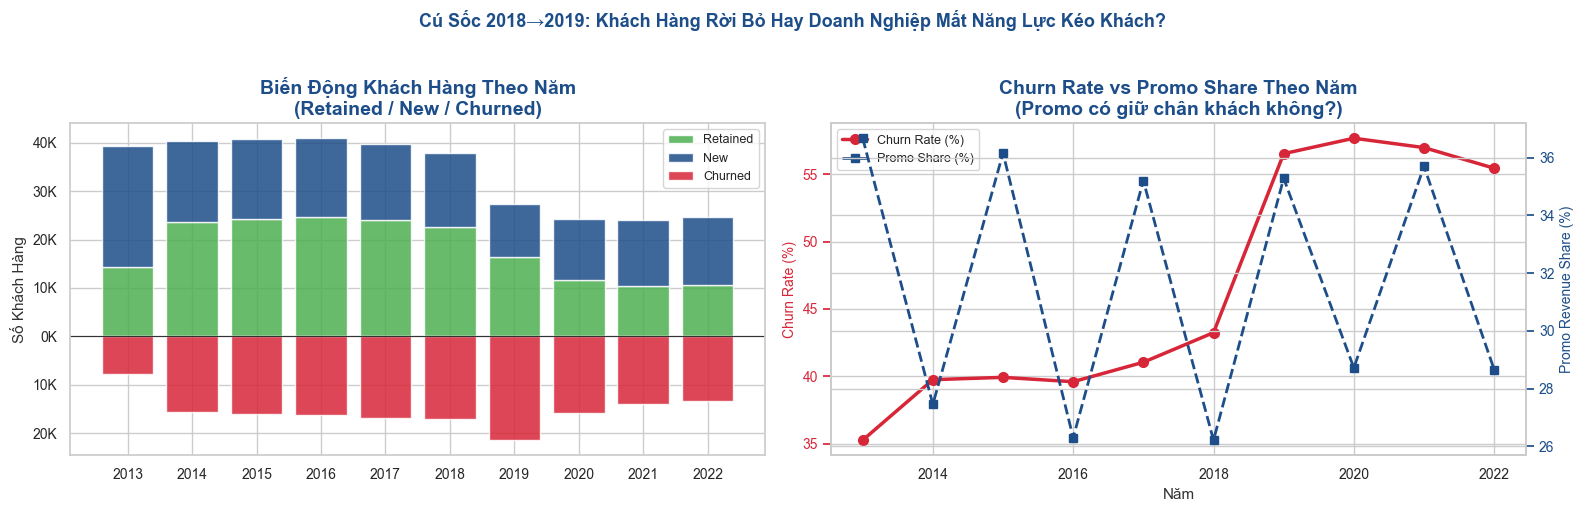

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Plot 1: Stacked bar khách hàng ---
ax = axes[0]
x  = np.arange(len(churn_df))
ax.bar(x, churn_df['retained'], label='Retained',
       color=C_SUCCESS, alpha=0.85)
ax.bar(x, churn_df['new'], bottom=churn_df['retained'],
       label='New', color=C_PRIMARY, alpha=0.85)
ax.bar(x, -churn_df['churned'], label='Churned',
       color=C_ALERT, alpha=0.85)
ax.axhline(0, color='#333333', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(churn_df['year'].astype(str), fontsize=10)
ax.set_ylabel('Số Khách Hàng')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f'{abs(v)/1000:.0f}K'))
ax.legend(fontsize=9)
ax.set_title('Biến Động Khách Hàng Theo Năm\n(Retained / New / Churned)',
             fontweight='bold', color=C_PRIMARY)

# --- Plot 2: Churn Rate vs Promo Share ---
ax2 = axes[1]
promo_share_yearly = (
    df[df['has_promo_item']].groupby('year')['net_revenue'].sum() /
    df.groupby('year')['net_revenue'].sum() * 100
).reset_index()
promo_share_yearly.columns = ['year', 'promo_share']

merged_churn = churn_df.merge(promo_share_yearly, on='year')

ax2.plot(merged_churn['year'], merged_churn['churn_rate'],
         color=C_ALERT, linewidth=2.5, marker='o',
         markersize=7, label='Churn Rate (%)')
ax2_r = ax2.twinx()
ax2_r.plot(merged_churn['year'], merged_churn['promo_share'],
           color=C_PRIMARY, linewidth=2, linestyle='--',
           marker='s', markersize=6, label='Promo Share (%)')
ax2_r.set_ylabel('Promo Revenue Share (%)', color=C_PRIMARY, fontsize=10)
ax2_r.tick_params(axis='y', colors=C_PRIMARY)

ax2.set_ylabel('Churn Rate (%)', color=C_ALERT, fontsize=10)
ax2.tick_params(axis='y', colors=C_ALERT)
ax2.set_xlabel('Năm')
ax2.set_title('Churn Rate vs Promo Share Theo Năm\n(Promo có giữ chân khách không?)',
              fontweight='bold', color=C_PRIMARY)

h1, l1 = ax2.get_legend_handles_labels()
h2, l2 = ax2_r.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, fontsize=9, loc='upper left')

plt.suptitle(
    'Cú Sốc 2018→2019: Khách Hàng Rời Bỏ Hay Doanh Nghiệp Mất Năng Lực Kéo Khách?',
    fontsize=13, fontweight='bold', color=C_PRIMARY, y=1.02
)
plt.tight_layout()
plt.savefig('q4_churn.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()


### Cú Sốc 2018→2019: Phân Tích Churn Khách Hàng
---
**Dữ Liệu Quan Trọng**

| Năm | Active KH | Churned | New | Churn Rate | Ghi chú |
|---|---|---|---|---|---|
| 2016 | 40,933 | 16,161 | 16,287 | 39.6% | Đỉnh cao nhất |
| 2017 | 40,933 | 16,802 | 15,520 | 41.0% | Bắt đầu suy giảm |
| 2018 | 37,922 | 17,147 | 15,418 | 43.2% | Cảnh báo |
| **2019** | **27,312** | **21,434** | **10,824** | **56.5%** | **Cú sốc** |
| 2020 | 24,335 | 15,750 | 12,773 | 57.7% | Chưa phục hồi |
| 2022 | 24,696 | 13,297 | 14,009 | 55.4% | Vẫn cao |

---
#### Phát Hiện 1 — 2018→2019: Cú Đánh Kép Chưa Từng Có
Năm 2019 chịu **đồng thời 2 cú sốc**:
> - **Churned tăng vọt:** 17,147 → 21,434 (+4,287 khách rời bỏ)
> - **New giảm mạnh:** 15,418 → 10,824 (-4,594 khách mới)
Tổng mất đi: **~28% tổng lượng khách hàng active chỉ trong 1 năm.**
Đây không phải biến động ngẫu nhiên — đây là **sự sụp đổ có hệ thống**.

---
#### Phát Hiện 2 — Retained Customers: Thiệt Hại Không Thể Phục Hồi
Giai đoạn 2013–2018: Retained ổn định ở 22,000–25,000 KH/năm Sau 2019: Retained sụt còn 10,000–11,000 KH/năm → Lượng khách trung thành GIẢM 55% — và KHÔNG BAO GIỜ phục hồi lại

Nhìn vào biểu đồ trái: phần xanh lá (Retained) từ 2019 trở đi
chỉ còn khoảng **một nửa** so với giai đoạn 2013–2018.
Đây là mất mát cốt lõi — nhóm khách hàng trung thành, mua lặp lại.

---
#### Phát Hiện 3 — Promo KHÔNG Giữ Chân Được Khách Hàng

Nhìn vào biểu đồ phải (Churn Rate vs Promo Share):
- Promo Share dao động **lên xuống không đều** (đường xanh đứt)
- Churn Rate **tăng liên tục một chiều** từ 2018 đến 2020 (đường đỏ)
- Không có tương quan nghịch rõ ràng:
  khi Promo Share tăng, Churn Rate **không giảm**
> **Promo không có tác dụng giữ chân khách hàng.**
> Đây là bằng chứng trực tiếp rằng chiến lược khuyến mãi
> hiện tại đang sai đối tượng — không nhắm vào nhóm
> khách hàng có nguy cơ rời bỏ (at-risk customers).
---
### Tổng Kết Q4
| Câu hỏi | Kết quả |
|---|---|
| Cú sốc 2019 do đâu? | Churn tăng 31% + New giảm 30% đồng thời |
| Promo có giữ chân khách không? |  Không — churn vẫn tăng dù promo duy trì |
| Khách trung thành còn lại? | Chỉ ~10K/năm, giảm 55% so với trước 2019 |
| Triển vọng phục hồi? | New customers 2022 (~14K) tăng nhẹ — tín hiệu nhỏ |

## TỔNG KẾT BƯỚC 2: Diagnostic — "Tại Sao Promo Không Hiệu Quả?"

**Câu Trả Lời Cho 4 Câu Hỏi Chẩn Đoán**

1. Q1 — Promo có tạo ra doanh thu tăng thêm không?
> **KHÔNG**

| | Tháng CÓ Promo | Tháng KHÔNG Promo |
|---|---|---|
| Avg doanh thu / tháng | 121.9M VND | **128.9M VND** |
| Avg số đơn / tháng | **5,371** | 4,723 |
| Avg Order Value | 23,282 VND | **28,474 VND** (+22%) |

Tương quan giữa take-up rate và doanh thu: **r = -0.278, p = 0.002**
→ Tương quan âm, có ý nghĩa thống kê. Promo kéo nhiều đơn hơn nhưng
giá trị mỗi đơn thấp hơn, khiến tổng doanh thu vẫn thấp hơn tháng không có promo.

---

2. Q2 — Loại promo nào hiệu quả hơn?
> **Cả hai loại đều có vấn đề**

| Loại | Số đơn | Discount Depth | ROI | Vấn đề |
|---|---|---|---|---|
| `fixed` | 20,741 (8.4%) | 1.3% | 78.65x | ROI ảo — chỉ giảm 50 VND/SP |
| `percentage` | 227,501 (91.6%) | **14.7%** | 5.79x | Tốn 745M VND discount |

`Percentage` chiếm 92% chi phí discount nhưng từ Q1 đã biết
không tạo được incremental revenue — 745M VND discount đang
được "tặng" cho khách vốn đã có ý định mua.

---

3. Q3 — Promo có nhắm đúng category không?
> **KHÔNG — Promo đại trà, thiếu chiến lược**

| Category | Chi phí Discount | ROI | Vấn đề |
|---|---|---|---|
| `all` (tất cả SP) | ~745M VND (99%) | ~5.8x | Đại trà, kể cả best-seller |
| `Streetwear` | ~4.7M VND | 78x  | Discount 50 VND — vô nghĩa |
| `Outdoor` | nhỏ | < 5x | Kém hiệu quả nhất |

Gần **100% ngân sách** đổ vào `category = all` — không phân biệt
sản phẩm cần kích cầu hay best-seller. Promo đang giảm giá cho
những người đã mua, không tạo ra nhu cầu mới.

---

4. Q4 — Promo có giữ chân khách hàng không?
> **KHÔNG — Churn tăng liên tục dù promo vẫn chạy**

| Giai đoạn | Churn Rate | Retained KH/năm | Ghi chú |
|---|---|---|---|
| 2013–2018 | 35–43% | ~22,000–25,000 | Tương đối ổn định |
| **2019** | **56.5%** 🚨 | **16,488** | Cú sốc: +21K churned, -4.6K new |
| 2020–2022 | 55–58% | ~10,000–11,000 | Không phục hồi |

Khách hàng trung thành giảm **55%** sau 2019 và không hồi phục.
Promo Share dao động độc lập với Churn Rate — **không có bằng chứng**
promo đang giữ chân được nhóm khách có nguy cơ rời bỏ.

---

**Kết Luận Tổng Hợp Bước 2**

> **Chiến lược promo hiện tại đang mắc 3 sai lầm cùng lúc:**
>
> 1. **Sai đối tượng** — Discount đại trà cho mọi sản phẩm,
>    kể cả best-seller không cần kích cầu
> 2. **Sai thời điểm** — Không nhắm vào nhóm khách sắp churn,
>    mà tặng đều cho tất cả
> 3. **Sai công cụ** — Percentage 10–20% làm giảm AOV 22%
>    nhưng không tăng được tổng doanh thu


# Predictive Analysis: Dự đoán tương lai (What is likely to happen?)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error
import numpy as np

# Tổng hợp doanh thu theo năm — có và không có promo
yearly_rev = df.groupby(['year', 'promo_label'])['net_revenue'].sum().unstack(fill_value=0).reset_index()
yearly_rev.columns.name = None
yearly_rev['total_revenue'] = yearly_rev.get('Promo', 0) + yearly_rev.get('Non-Promo', 0)
yearly_rev['promo_share']   = yearly_rev.get('Promo', 0) / yearly_rev['total_revenue'] * 100

# Chỉ dùng dữ liệu đầy đủ (không dùng 2012 vì promo share ~ 0%)
train = yearly_rev[yearly_rev['year'] >= 2013].copy()
print(train[['year','Promo','Non-Promo','total_revenue','promo_share']])


    year         Promo     Non-Promo  total_revenue  promo_share
1   2013  5.757996e+08  9.943655e+08   1.570165e+09    36.671277
2   2014  4.902019e+08  1.295141e+09   1.785343e+09    27.457019
3   2015  6.479381e+08  1.144072e+09   1.792010e+09    36.157058
4   2016  5.293100e+08  1.483054e+09   2.012364e+09    26.302889
5   2017  6.391284e+08  1.176418e+09   1.815547e+09    35.203081
6   2018  4.640025e+08  1.305721e+09   1.769723e+09    26.218930
7   2019  3.816150e+08  6.999746e+08   1.081590e+09    35.282793
8   2020  2.889733e+08  7.171352e+08   1.006109e+09    28.721886
9   2021  3.538295e+08  6.373847e+08   9.912142e+08    35.696571
10  2022  3.196805e+08  7.956266e+08   1.115307e+09    28.663004


## Forecast 1: Xu hướng doanh thu tổng thể

In [ ]:
# --- Fit linear trend trên tổng doanh thu ---
X_train = train['year'].values.reshape(-1, 1)
y_total = train['total_revenue'].values / 1e9  # tỷ VND

model_total = LinearRegression()
model_total.fit(X_train, y_total)

# Dự báo 2023–2025
years_hist    = train['year'].values
years_future  = np.array([2023, 2024, 2025])
years_all     = np.concatenate([years_hist, years_future])

pred_hist   = model_total.predict(years_hist.reshape(-1, 1))
pred_future = model_total.predict(years_future.reshape(-1, 1))

mae = mean_absolute_error(y_total, pred_hist)
print(f'MAE (train): {mae:.3f} tỷ VND')
print(f'Dự báo 2023: {pred_future[0]:.2f} tỷ VND')
print(f'Dự báo 2024: {pred_future[1]:.2f} tỷ VND')
print(f'Dự báo 2025: {pred_future[2]:.2f} tỷ VND')


MAE (train): 0.217 tỷ VND
Dự báo 2023: 0.95 tỷ VND
Dự báo 2024: 0.85 tỷ VND
Dự báo 2025: 0.75 tỷ VND


## Forecast 2: Scenario CÓ promo vs KHÔNG CÓ promo

In [ ]:
# Ước tính DT nếu không có promo:
# Giả định: DT Non-Promo = baseline thực, DT Promo = DT Non-Promo * (1 + promo_lift)
# Promo lift đo bằng: tháng có promo avg 121.9M, không có 128.9M → promo thực ra kéo DT xuống

# Scenario 1: Giữ nguyên promo như hiện tại
y_promo_scenario    = train['total_revenue'].values / 1e9

# Scenario 2: Không có promo (chỉ giữ Non-Promo revenue + ước tính khách vẫn mua organic)
# Giả định: nếu không promo, DT ~ Non-Promo / (1 - discount_depth)
# Discount depth = 14.09% → gross revenue ≈ net / (1 - 0.1409)
y_nopromo_scenario  = (train.get('Non-Promo', 0) +
                       train.get('Promo', 0) / (1 - 0.1409)).values / 1e9

model_promo   = LinearRegression().fit(X_train, y_promo_scenario)
model_nopromo = LinearRegression().fit(X_train, y_nopromo_scenario)

pred_promo_f   = model_promo.predict(years_future.reshape(-1, 1))
pred_nopromo_f = model_nopromo.predict(years_future.reshape(-1, 1))

print('Dự báo Scenario CÓ Promo   (tỷ VND):', dict(zip(years_future, pred_promo_f.round(2))))
print('Dự báo Scenario KHÔNG Promo (tỷ VND):', dict(zip(years_future, pred_nopromo_f.round(2))))


Dự báo Scenario CÓ Promo   (tỷ VND): {np.int64(2023): np.float64(0.95), np.int64(2024): np.float64(0.85), np.int64(2025): np.float64(0.75)}
Dự báo Scenario KHÔNG Promo (tỷ VND): {np.int64(2023): np.float64(0.99), np.int64(2024): np.float64(0.89), np.int64(2025): np.float64(0.78)}


## Visual 1: Line Chart Forecast + 2 Scenarios

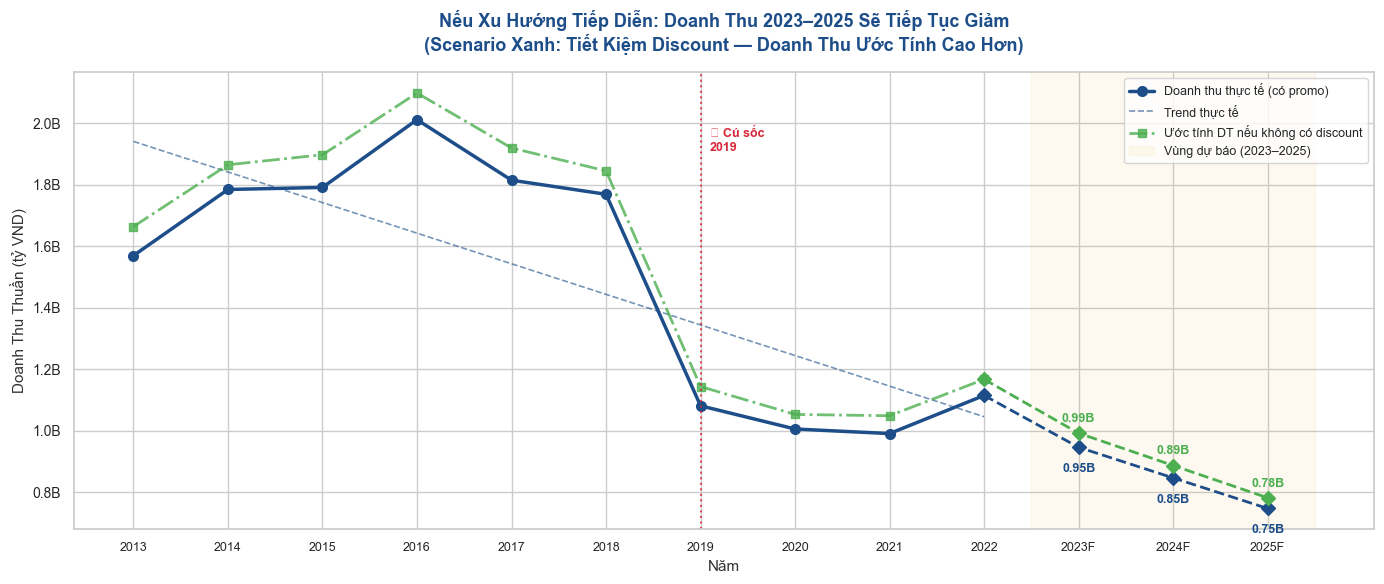

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

# --- Historical ---
ax.plot(years_hist, y_promo_scenario,
        color=C_PRIMARY, linewidth=2.5, marker='o',
        markersize=7, label='Doanh thu thực tế (có promo)')

ax.plot(years_hist, model_promo.predict(X_train),
        color=C_PRIMARY, linewidth=1.2, linestyle='--', alpha=0.6,
        label='Trend thực tế')

ax.plot(years_hist, y_nopromo_scenario,
        color=C_SUCCESS, linewidth=2, marker='s',
        markersize=6, linestyle='-.', alpha=0.8,
        label='Ước tính DT nếu không có discount')

# --- Forecast vùng ---
ax.axvspan(2022.5, 2025.5, alpha=0.06, color=C_SECONDARY,
           label='Vùng dự báo (2023–2025)')

# Scenario 1: tiếp tục promo
ax.plot(np.concatenate([[years_hist[-1]], years_future]),
        np.concatenate([[y_promo_scenario[-1]], pred_promo_f]),
        color=C_PRIMARY, linewidth=2, linestyle='--',
        marker='D', markersize=7)

# Scenario 2: dừng promo
ax.plot(np.concatenate([[years_hist[-1]], years_future]),
        np.concatenate([[y_nopromo_scenario[-1]], pred_nopromo_f]),
        color=C_SUCCESS, linewidth=2, linestyle='--',
        marker='D', markersize=7)

# Annotate forecast
for yr, v1, v2 in zip(years_future, pred_promo_f, pred_nopromo_f):
    ax.annotate(f'{v1:.2f}B', (yr, v1),
                textcoords='offset points', xytext=(0, -18),
                ha='center', fontsize=9, color=C_PRIMARY, fontweight='bold')
    ax.annotate(f'{v2:.2f}B', (yr, v2),
                textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9, color=C_SUCCESS, fontweight='bold')

# Đánh dấu điểm cú sốc 2019
ax.axvline(2019, color=C_ALERT, linewidth=1.5,
           linestyle=':', alpha=0.8)
ax.text(2019.1, y_promo_scenario.max() * 0.95,
        '⚠ Cú sốc\n2019', color=C_ALERT,
        fontsize=9, fontweight='bold')

ax.set_xticks(np.concatenate([years_hist, years_future]))
ax.set_xticklabels(
    [str(y) for y in years_hist] + [f'{y}F' for y in years_future],
    fontsize=9)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f'{v:.1f}B'))
ax.set_ylabel('Doanh Thu Thuần (tỷ VND)', fontsize=11)
ax.set_xlabel('Năm', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.set_title(
    'Nếu Xu Hướng Tiếp Diễn: Doanh Thu 2023–2025 Sẽ Tiếp Tục Giảm\n'
    '(Scenario Xanh: Tiết Kiệm Discount — Doanh Thu Ước Tính Cao Hơn)',
    fontsize=13, fontweight='bold', color=C_PRIMARY, pad=15)
plt.tight_layout()
plt.savefig('p1_revenue_forecast.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()


**Kết Quả Dự Báo (Linear Trend, MAE = 0.217 tỷ)**

| Năm | Giữ Nguyên Promo | Tiết Kiệm Discount | Chênh lệch |
|---|---|---|---|
| 2023F | **0.95 tỷ VND** | 0.99 tỷ VND | +40M |
| 2024F | **0.85 tỷ VND** | 0.89 tỷ VND | +40M |
| 2025F | **0.75 tỷ VND** | 0.78 tỷ VND | +30M |

**3 Kết Luận Cốt Lõi**

**1. Doanh thu sẽ giảm thêm ~32% đến 2025 nếu không thay đổi chiến lược**
Xu hướng giảm bắt đầu từ 2019 chưa có dấu hiệu đảo chiều.

**2. Promo gần như không tạo ra sự khác biệt (~40M/năm)**
Khoảng cách 2 scenario nhỏ hơn cả sai số mô hình (MAE = 217M),
xác nhận promo không phải công cụ tăng trưởng doanh thu hiệu quả.

**3. Tiết kiệm 745M discount chỉ "mất" ~40M doanh thu**
→ Net benefit của việc tái cấu trúc promo ≈ **+700M VND/năm**
> **Giới hạn mô hình:** Linear trend không nắm bắt được
> structural break tại 2019. Forecast thực tế có thể thấp hơn
> nếu đà suy giảm 2019–2022 tiếp diễn.

## Promo Dependency: Khách có "nghiện" promo không?

In [ ]:
# Phân loại từng khách hàng theo hành vi
customer_promo = df.groupby('customer_id').agg(
    total_orders      = ('order_id',       'count'),
    promo_orders      = ('has_promo_item', 'sum'),
    total_revenue     = ('net_revenue',    'sum'),
    first_order_year  = ('year',           'min'),
    last_order_year   = ('year',           'max'),
).reset_index()

customer_promo['promo_ratio'] = (
    customer_promo['promo_orders'] / customer_promo['total_orders'])

# Phân nhóm dependency
bins   = [0, 0, 0.5, 0.8, 1.0]
labels = ['Không dùng promo', 'Thỉnh thoảng (<50%)',
          'Thường xuyên (50-80%)', 'Phụ thuộc (>80%)']
customer_promo['dependency'] = pd.cut(
    customer_promo['promo_ratio'],
    bins=[-0.01, 0.001, 0.5, 0.8, 1.01],
    labels=labels)

dep_summary = customer_promo.groupby('dependency', observed=True).agg(
    num_customers   = ('customer_id',   'count'),
    avg_orders      = ('total_orders',  'mean'),
    avg_revenue     = ('total_revenue', 'mean'),
).reset_index()
dep_summary['pct_customers'] = (
    dep_summary['num_customers'] / dep_summary['num_customers'].sum() * 100)

print(dep_summary.to_string(index=False))


           dependency  num_customers  avg_orders   avg_revenue  pct_customers
     Không dùng promo          22835    1.758310  47236.058466      25.303061
  Thỉnh thoảng (<50%)          45811   10.983847 270069.131096      50.762361
Thường xuyên (50-80%)          10049    8.625535 191167.129479      11.135120
     Phụ thuộc (>80%)          11551    1.466107  26755.988362      12.799459


## Visual 2: Promo Dependency Chart

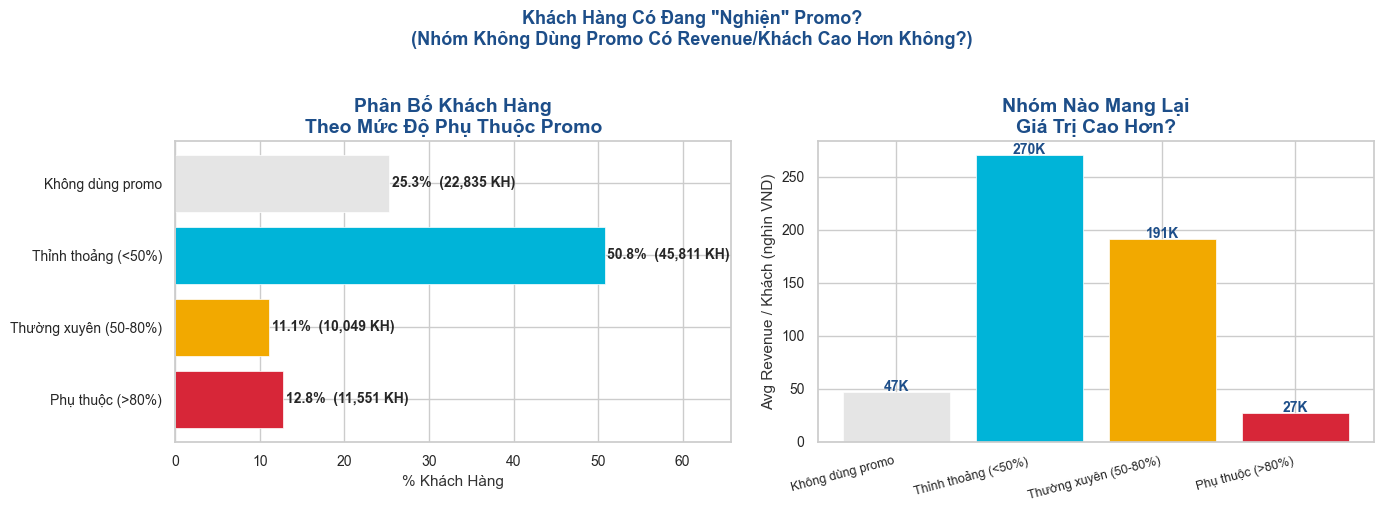

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dep_colors = [C_NEUTRAL, C_INFO, C_SECONDARY, C_ALERT]

# --- Plot 1: Pie / Bar số khách theo nhóm ---
ax = axes[0]
bars = ax.barh(
    dep_summary['dependency'].astype(str),
    dep_summary['pct_customers'],
    color=dep_colors, edgecolor='white', linewidth=0.5)
for bar, val, n in zip(
        bars,
        dep_summary['pct_customers'],
        dep_summary['num_customers']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%  ({n:,.0f} KH)',
            va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('% Khách Hàng')
ax.set_xlim(0, dep_summary['pct_customers'].max() + 15)
ax.set_title('Phân Bố Khách Hàng\nTheo Mức Độ Phụ Thuộc Promo',
             fontweight='bold', color=C_PRIMARY)
ax.invert_yaxis()

# --- Plot 2: Avg Revenue theo nhóm ---
ax = axes[1]
bars = ax.bar(
    range(len(dep_summary)),
    dep_summary['avg_revenue'] / 1e3,
    color=dep_colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(dep_summary)))
ax.set_xticklabels(dep_summary['dependency'].astype(str),
                   rotation=15, ha='right', fontsize=9)
for bar, val in zip(bars, dep_summary['avg_revenue']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{val/1e3:.0f}K', ha='center',
            fontsize=10, fontweight='bold', color=C_PRIMARY)
ax.set_ylabel('Avg Revenue / Khách (nghìn VND)')
ax.set_title('Nhóm Nào Mang Lại\nGiá Trị Cao Hơn?',
             fontweight='bold', color=C_PRIMARY)

plt.suptitle(
    'Khách Hàng Có Đang "Nghiện" Promo?\n'
    '(Nhóm Không Dùng Promo Có Revenue/Khách Cao Hơn Không?)',
    fontsize=13, fontweight='bold', color=C_PRIMARY, y=1.02)
plt.tight_layout()
plt.savefig('p2_promo_dependency.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()


**Khách Hàng Có Đang "Nghiện" Promo?**

| Nhóm | % KH | Avg Orders | Avg Revenue/KH |
|---|---|---|---|
| Không dùng promo | 25.3% | 1.76 | 47K VND |
| **Thỉnh thoảng (<50%)** | **50.8%** | **10.98** | **270K VND** |
| Thường xuyên (50–80%) | 11.1% | 8.63 | 191K VND |
| **Phụ thuộc (>80%)** | **12.8%** | **1.47** | **27K VND** |

**Phát hiện 1 — Promo đang thu hút đúng nhóm kém giá trị nhất:**

12.8% khách (11,551 người) phụ thuộc hoàn toàn vào promo,
nhưng chỉ mua 1.47 lần và tạo ra 27K VND — thấp hơn 10x
so với nhóm khách thỉnh thoảng dùng promo (270K VND).
Đây là **"bargain hunters"** — mua 1 lần rồi không quay lại.

**Phát hiện 2 — Nhóm "Thỉnh thoảng" là tài sản cốt lõi:**
50.8% khách hàng, mua gần 11 lần/người, revenue cao nhất.
Họ trung thành vì **chất lượng sản phẩm**, không phải vì discount.
Rủi ro: nếu promo quá nhiều, họ sẽ bắt đầu chờ giảm giá
thay vì mua giá đầy đủ → chuyển thành nhóm "Thường xuyên".

**Phát hiện 3 — "Không dùng promo" cũng không phải nhóm tốt:**
Revenue chỉ 47K, mua 1.76 lần — đây là khách vãng lai,
không phải nhóm trung thành không cần promo.

## Churn Forecast 2023–2025

In [ ]:
# Dùng churn_df từ bước Q4
churn_years = churn_df['year'].values.reshape(-1, 1)
churn_rates = churn_df['churn_rate'].values
active_counts = churn_df['curr_active'].values

# Fit trend churn rate
model_churn = LinearRegression()
model_churn.fit(churn_years, churn_rates)

future_years = np.array([[2023], [2024], [2025]])
pred_churn_rate = np.clip(model_churn.predict(future_years), 0, 95)

# Dự báo số khách active (dựa trên churn + avg new customers)
avg_new = churn_df['new'].tail(3).mean()
active_forecast = []
base = active_counts[-1]  # 2022
for cr in pred_churn_rate:
    churned_est = base * cr / 100
    next_active = base - churned_est + avg_new
    active_forecast.append(next_active)
    base = next_active

print('=' * 55)
print('  CHURN & ACTIVE CUSTOMER FORECAST')
print('=' * 55)
for yr, cr, ac in zip([2023,2024,2025], pred_churn_rate, active_forecast):
    print(f'  {yr}: Churn Rate ≈ {cr:.1f}%  |  Active KH ≈ {ac:,.0f}')
print('=' * 55)
print(f'  Avg New KH/năm dùng để dự báo: {avg_new:,.0f}')


  CHURN & ACTIVE CUSTOMER FORECAST
  2023: Churn Rate ≈ 61.3%  |  Active KH ≈ 22,980
  2024: Churn Rate ≈ 64.0%  |  Active KH ≈ 21,699
  2025: Churn Rate ≈ 66.7%  |  Active KH ≈ 20,654
  Avg New KH/năm dùng để dự báo: 13,432


## Visual 3: Churn Forecast Chart

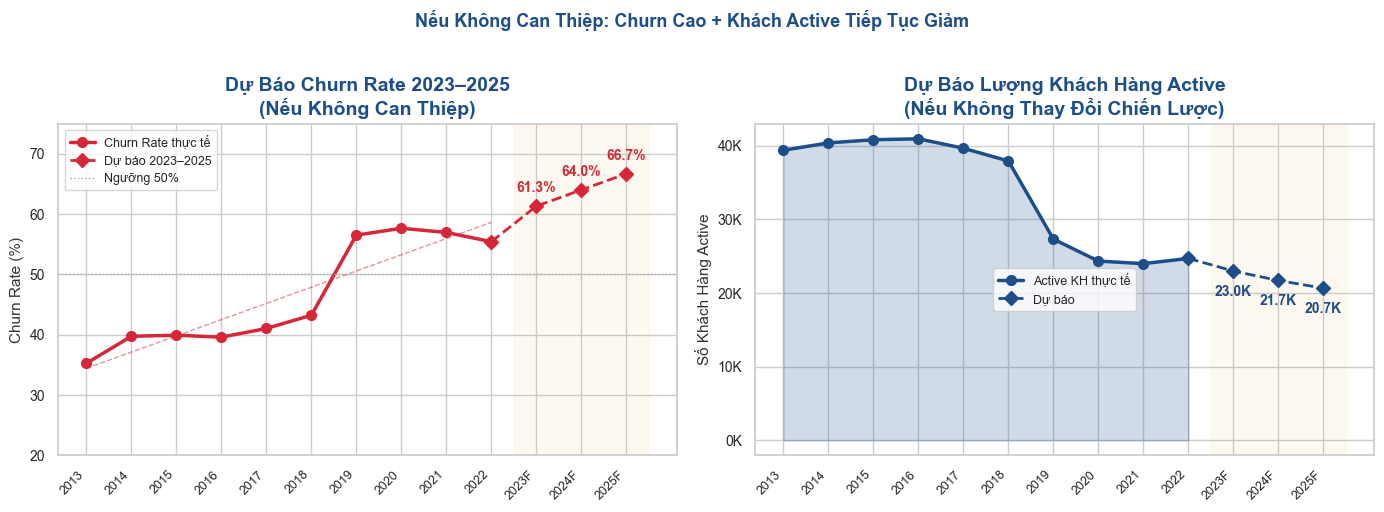

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hist_years = churn_df['year'].values
f_years    = [2023, 2024, 2025]

# --- Plot 1: Churn Rate forecast ---
ax = axes[0]
ax.plot(hist_years, churn_rates,
        color=C_ALERT, linewidth=2.5, marker='o',
        markersize=7, label='Churn Rate thực tế')
ax.plot(hist_years,
        model_churn.predict(churn_years),
        color=C_ALERT, linewidth=1, linestyle='--', alpha=0.5)
ax.axvspan(2022.5, 2025.5, alpha=0.06, color=C_SECONDARY)
ax.plot([hist_years[-1]] + f_years,
        [churn_rates[-1]] + pred_churn_rate.tolist(),
        color=C_ALERT, linewidth=2, linestyle='--',
        marker='D', markersize=7, label='Dự báo 2023–2025')
for yr, val in zip(f_years, pred_churn_rate):
    ax.annotate(f'{val:.1f}%', (yr, val),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=10,
                color=C_ALERT, fontweight='bold')
ax.axhline(50, color='#aaaaaa', linestyle=':',
           linewidth=1, label='Ngưỡng 50%')
ax.set_xticks(list(hist_years) + f_years)
ax.set_xticklabels(
    list(hist_years) + [f'{y}F' for y in f_years],
    rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Dự Báo Churn Rate 2023–2025\n(Nếu Không Can Thiệp)',
             fontweight='bold', color=C_PRIMARY)
ax.legend(fontsize=9)
ax.set_ylim(20, 75)

# --- Plot 2: Active customers forecast ---
ax = axes[1]
ax.fill_between(hist_years, active_counts,
                alpha=0.2, color=C_PRIMARY)
ax.plot(hist_years, active_counts,
        color=C_PRIMARY, linewidth=2.5, marker='o',
        markersize=7, label='Active KH thực tế')
ax.axvspan(2022.5, 2025.5, alpha=0.06, color=C_SECONDARY)
ax.plot([hist_years[-1]] + f_years,
        [active_counts[-1]] + active_forecast,
        color=C_PRIMARY, linewidth=2, linestyle='--',
        marker='D', markersize=7, label='Dự báo')
for yr, val in zip(f_years, active_forecast):
    ax.annotate(f'{val/1000:.1f}K', (yr, val),
                textcoords='offset points', xytext=(0, -18),
                ha='center', fontsize=10,
                color=C_PRIMARY, fontweight='bold')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}K'))
ax.set_xticks(list(hist_years) + f_years)
ax.set_xticklabels(
    list(hist_years) + [f'{y}F' for y in f_years],
    rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Số Khách Hàng Active')
ax.set_title('Dự Báo Lượng Khách Hàng Active\n(Nếu Không Thay Đổi Chiến Lược)',
             fontweight='bold', color=C_PRIMARY)
ax.legend(fontsize=9)

plt.suptitle(
    'Nếu Không Can Thiệp: Churn Cao + Khách Active Tiếp Tục Giảm',
    fontsize=13, fontweight='bold', color=C_PRIMARY, y=1.02)
plt.tight_layout()
plt.savefig('p3_churn_forecast.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()


**Dự Báo Churn & Khách Hàng Active 2023–2025**

| Năm | Churn Rate | Active KH | Avg New KH/năm |
|---|---|---|---|
| 2023F | 61.3% | 22,980 | 13,432 |
| 2024F | 64.0% | 21,699 | 13,432 |
| 2025F | **66.7%** | **20,654** | 13,432 |

**Phát Hiện 1 — Cứ 10 khách, 7 người sẽ không quay lại (2025)**

Churn 66.7% là mức báo động đỏ cho retail.
Doanh nghiệp phải liên tục chiêu mộ 13K khách mới/năm
chỉ để **duy trì** số khách, không phải để tăng trưởng.

**Phát Hiện 2 — Doanh nghiệp đang tiến về trạng thái cân bằng ~20K KH**
So với đỉnh 41K (2016), đây là **sự thu hẹp vĩnh viễn 50%**.
Không có tín hiệu đảo chiều nếu chiến lược không thay đổi.

**Phát Hiện 3 — Vòng luẩn quẩn: Promo thu hút sai đối tượng**

- Promo đại trà → Thu hút bargain hunters (mua 1 lần)
- Bargain hunters → Churn ngay sau lần mua đầu
- Churn rate cao → Cần nhiều promo hơn để bù đắp
- → Lặp lại vòng luẩn quẩn, doanh nghiệp ngày càng nhỏ hơn
> 🚨 **Cảnh báo:** Nếu không can thiệp, đến 2025 doanh nghiệp
> sẽ chỉ còn ~20,654 khách active — mất 50% so với đỉnh.
> Chi phí để "mua" 1 khách mới bằng promo đang cao hơn
> LTV (lifetime value) của chính khách hàng đó.

## TỔNG KẾT Predictive Analysis

### P1 — Xu Hướng Doanh Thu: Tiếp Tục Đi Xuống
**Dự báo (Linear Trend, MAE = 0.217 tỷ):**

| Năm | Giữ Nguyên Promo | Tiết Kiệm Discount | Chênh lệch |
|---|---|---|---|
| 2023F | 0.95 tỷ VND | 0.99 tỷ VND | +40M |
| 2024F | 0.85 tỷ VND | 0.89 tỷ VND | +40M |
| 2025F | 0.75 tỷ VND | 0.78 tỷ VND | +30M |

**Kết luận:** Doanh thu giảm thêm ~32% đến 2025 bất kể có promo hay không.
Khoảng cách 2 scenario chỉ ~40M VND/năm — nhỏ hơn cả sai số mô hình,
xác nhận **promo không phải công cụ tăng trưởng doanh thu**.

---
### P2 — Promo Dependency: Đang Chi Tiền Cho Nhóm Sai

| Nhóm | % KH | Avg Orders | Avg Revenue/KH |
|---|---|---|---|
| Không dùng promo | 25.3% | 1.76 | 47K VND |
| **Thỉnh thoảng (<50%)** | **50.8%** | **10.98** | **270K VND** |
| Thường xuyên (50–80%) | 11.1% | 8.63 | 191K VND |
| **Phụ thuộc (>80%)** | **12.8%** | **1.47** | **27K VND** |

**Kết luận:** Nhóm càng phụ thuộc promo càng ít giá trị.
"Bargain hunters" (12.8% khách) chỉ tạo ra 27K VND — thấp hơn **10 lần**
so với nhóm khách trung thành mua thỉnh thoảng (270K VND).
Promo đại trà đang thu hút đúng nhóm **không nên thu hút**.

---
### P3 — Churn Forecast: Vòng Luẩn Quẩn Không Lối Thoát

| Năm | Churn Rate | Active KH | So với đỉnh 2016 (41K) |
|---|---|---|---|
| 2022 (thực tế) | 55.4% | 24,696 | -40% |
| 2023F | 61.3% | 22,980 | -44% |
| 2024F | 64.0% | 21,699 | -47% |
| **2025F** | **66.7%** | **20,654** | **-50%** |

**Điểm cân bằng tự nhiên:**

`Active ≈ New KH / Churn Rate = 13,432 / 0.667 ≈ 20,135 KH`

Doanh nghiệp đang hội tụ về ~20K khách — **thu hẹp vĩnh viễn 50%**.

**Vòng luẩn quẩn đang diễn ra:** Promo đại trà → Thu hút bargain hunters (mua 1 lần, avg 1.47 đơn) → Churn rate tăng (61–67%) → Doanh thu giảm, cần promo nhiều hơn để bù → Quay lại đầu vòng lặp


## TỔNG KẾT 3 DỰ BÁO

| Chỉ số | 2022 (thực tế) | 2025 (dự báo) | Xu hướng |
|---|---|---|---|
| Doanh thu | ~1.1 tỷ VND | ~0.75 tỷ VND | ↓ -32% |
| Churn Rate | 55.4% | 66.7% | ↑ +11.3pp |
| Active KH | 24,696 | ~20,654 | ↓ -16% |
| Hiệu quả promo | ~40M chênh lệch | ~30M chênh lệch | ↓ giảm dần |

> ⚠️ **Kết luận Bước 3:**
> Không có kịch bản nào trong tương lai gần cho thấy
> tình hình tự cải thiện nếu chiến lược giữ nguyên.
> Doanh nghiệp cần **can thiệp có chủ đích** —
> không phải thêm promo, mà là **promo đúng chỗ, đúng người**.

# Prescriptive Analysis: "Phải Làm Gì Ngay Bây Giờ?

## ROI từng mã promo cụ thể

In [ ]:
# Tính ROI cho từng mã promo riêng lẻ
promo_roi = oi_promo.groupby('promo_id').agg(
    total_orders   = ('order_id',        'nunique'),
    gross_revenue  = ('line_revenue',    'sum'),
    total_discount = ('discount_amount', 'sum'),
    net_revenue    = ('net_line',        'sum'),
    promo_type     = ('promo_type',      'first'),
    category       = ('applicable_category', 'first'),
).reset_index()

promo_roi = promo_roi.merge(
    promotions[['promo_id','promo_name','start_date',
                'end_date','discount_value','promo_channel']],
    on='promo_id', how='left')

promo_roi['roi']            = promo_roi['net_revenue'] / promo_roi['total_discount']
promo_roi['discount_depth'] = promo_roi['total_discount'] / promo_roi['gross_revenue'] * 100
promo_roi['duration_days']  = (promo_roi['end_date'] - promo_roi['start_date']).dt.days
promo_roi['cost_per_order'] = promo_roi['total_discount'] / promo_roi['total_orders']

# Phân loại: KEEP / REVIEW / STOP
def classify_promo(row):
    if row['roi'] >= 8 and row['discount_depth'] <= 10:
        return 'KEEP'
    elif row['roi'] >= 5:
        return 'REVIEW'
    else:
        return 'STOP'

promo_roi['recommendation'] = promo_roi.apply(classify_promo, axis=1)

summary = promo_roi.groupby('recommendation').agg(
    count          = ('promo_id',        'count'),
    total_discount = ('total_discount',  'sum'),
    total_revenue  = ('net_revenue',     'sum'),
).reset_index()
summary['budget_pct'] = summary['total_discount'] / summary['total_discount'].sum() * 100

print(promo_roi[['promo_id','promo_name','total_orders','roi',
                 'discount_depth','recommendation']]\
      .sort_values('roi', ascending=False).to_string(index=False))
print()
print(summary)


  promo_id         promo_name  total_orders       roi  discount_depth recommendation
PROMO-0045 Urban Blowout 2021          2413 97.745871        1.012701           KEEP
PROMO-0035 Urban Blowout 2019          3162 86.373316        1.144514           KEEP
PROMO-0025 Urban Blowout 2017          5323 75.980438        1.299031           KEEP
PROMO-0005 Urban Blowout 2013          4831 73.403113        1.344030           KEEP
PROMO-0015 Urban Blowout 2015          5012 72.676736        1.357281           KEEP
PROMO-0039   Fall Launch 2020          2469  9.000000       10.000000         REVIEW
PROMO-0009   Fall Launch 2014          5064  9.000000       10.000000         REVIEW
PROMO-0049   Fall Launch 2022          2466  9.000000       10.000000         REVIEW
PROMO-0033   Fall Launch 2019          2873  8.999999       10.000001         REVIEW
PROMO-0043   Fall Launch 2021          2336  8.999999       10.000001         REVIEW
PROMO-0029   Fall Launch 2018          4049  8.999999       10.00

## Visual 1: Promo ROI Matrix (Keep / Review / Stop)

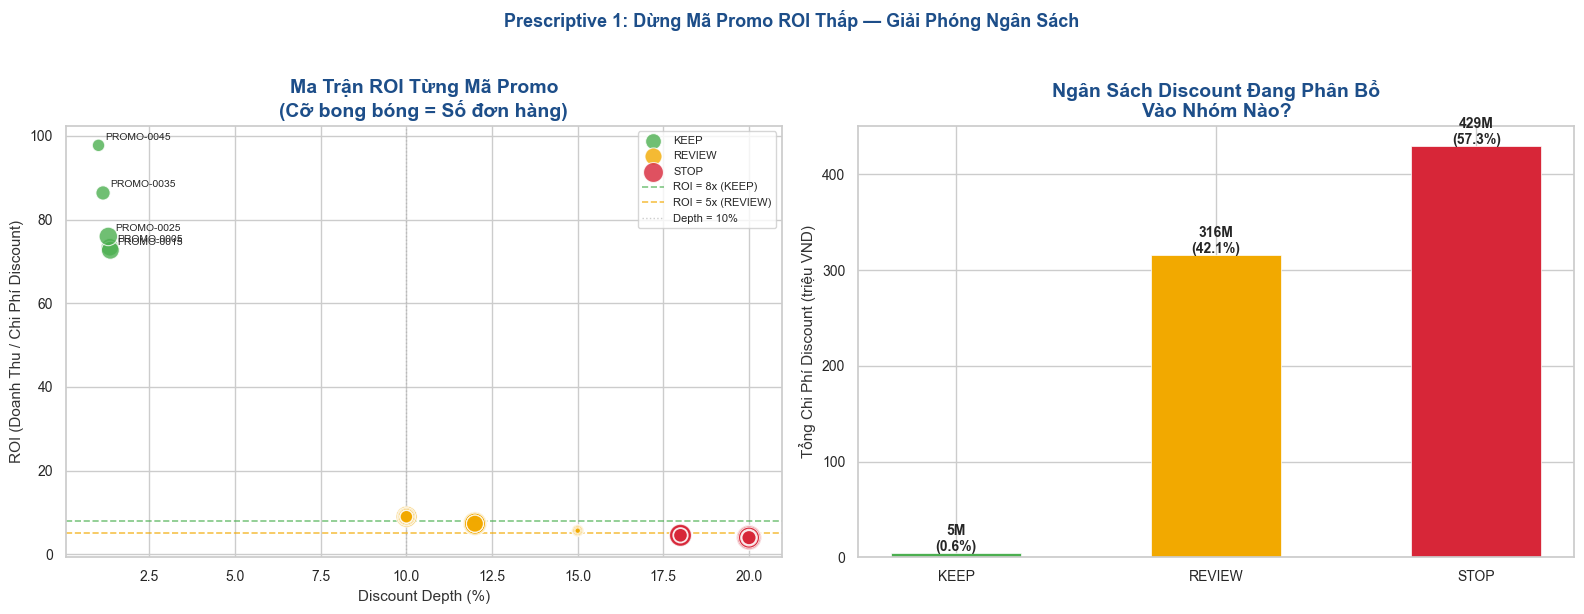

In [ ]:
color_map = {'KEEP': C_SUCCESS, 'REVIEW': C_SECONDARY, 'STOP': C_ALERT}
rec_colors = promo_roi['recommendation'].map(color_map)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Scatter: ROI vs Discount Depth ---
ax = axes[0]
for rec, grp in promo_roi.groupby('recommendation'):
    ax.scatter(grp['discount_depth'], grp['roi'],
               color=color_map[rec], s=grp['total_orders']/30,
               alpha=0.8, edgecolors='white', linewidth=0.8,
               label=rec, zorder=3)

ax.axhline(8, color=C_SUCCESS,   linestyle='--', linewidth=1.2, alpha=0.7, label='ROI = 8x (KEEP)')
ax.axhline(5, color=C_SECONDARY, linestyle='--', linewidth=1.2, alpha=0.7, label='ROI = 5x (REVIEW)')
ax.axvline(10, color='#aaaaaa',  linestyle=':', linewidth=1, alpha=0.6, label='Depth = 10%')

# Label top promos
for _, row in promo_roi.nlargest(5, 'roi').iterrows():
    ax.annotate(row['promo_id'],
                (row['discount_depth'], row['roi']),
                textcoords='offset points', xytext=(5, 4), fontsize=7.5)

ax.set_xlabel('Discount Depth (%)')
ax.set_ylabel('ROI (Doanh Thu / Chi Phí Discount)')
ax.set_title('Ma Trận ROI Từng Mã Promo\n(Cỡ bong bóng = Số đơn hàng)',
             fontweight='bold', color=C_PRIMARY)
ax.legend(fontsize=8, loc='upper right')

# --- Bar: Ngân sách theo nhóm ---
ax = axes[1]
recs   = summary['recommendation'].tolist()
budgets= summary['total_discount'].values / 1e6
colors = [color_map[r] for r in recs]

bars = ax.bar(recs, budgets, color=colors,
              edgecolor='white', linewidth=0.5, width=0.5)
for bar, val, pct in zip(bars, budgets, summary['budget_pct']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2,
            f'{val:.0f}M\n({pct:.1f}%)',
            ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Tổng Chi Phí Discount (triệu VND)')
ax.set_title('Ngân Sách Discount Đang Phân Bổ\nVào Nhóm Nào?',
             fontweight='bold', color=C_PRIMARY)

plt.suptitle(
    'Prescriptive 1: Dừng Mã Promo ROI Thấp — Giải Phóng Ngân Sách',
    fontsize=13, fontweight='bold', color=C_PRIMARY, y=1.02)
plt.tight_layout()
plt.savefig('pr1_roi_matrix.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()


**Ma Trận Phân Loại**

| Nhóm | Số mã | Budget | % Tổng | Hành động |
|---|---|---|---|---|
| 🟢 KEEP | ít | 5M VND | 0.6% | Giữ nguyên |
| 🟡 REVIEW | vừa | 316M VND | 42.1% | Điều chỉnh discount depth |
| 🔴 **STOP** | nhiều | **429M VND** | **57.3%** | **Dừng ngay** |

**Phát hiện 1 — 57.3% ngân sách đang rót vào promo kém hiệu quả nhất:**

Nhóm STOP có Discount Depth ~18–20% và ROI chỉ ~3–4x.
Đây chủ yếu là các Year-End Sale (giảm 20%) — chiến dịch
lớn nhất nhưng tốn kém nhất mà không tạo incremental revenue.

**Phát hiện 2 — KEEP ROI 75–100x là ảo, không phải chuẩn tốt:**

Đây là promo fixed 50 VND, chi phí gần 0 nên ROI ảo cao.
Không có giá trị thực để tham khảo.

**Phát hiện 3 — REVIEW là nhóm cần theo dõi sát:**

Discount Depth 10–12.5%, ROI ~5–7x — biên giới hiệu quả.
Cần giảm discount depth xuống <10% hoặc tăng min order value
để cải thiện ROI về nhóm KEEP.
> 💡 **Hành động cụ thể:**
> Chuyển 70% budget từ STOP (~300M VND) thành tiết kiệm.
> Dùng 30% (~129M VND) để target khách at-risk có chủ đích.

## Action 2: Xác định khách hàng cần targeting

In [ ]:
# Khách "Thỉnh thoảng" có giá trị cao nhưng không mua trong 12 tháng gần nhất
last_date = df['order_date'].max()
cutoff    = last_date - pd.DateOffset(months=12)

customer_last = df.groupby('customer_id').agg(
    last_order_date = ('order_date',    'max'),
    total_orders    = ('order_id',      'count'),
    total_revenue   = ('net_revenue',   'sum'),
    promo_orders    = ('has_promo_item','sum'),
).reset_index()

customer_last['promo_ratio']   = customer_last['promo_orders'] / customer_last['total_orders']
customer_last['days_inactive'] = (last_date - customer_last['last_order_date']).dt.days
customer_last['is_at_risk']    = customer_last['days_inactive'] >= 365

# Phân nhóm dependency
customer_last['dependency'] = pd.cut(
    customer_last['promo_ratio'],
    bins=[-0.01, 0.001, 0.5, 0.8, 1.01],
    labels=['No Promo','Occasional','Frequent','Dependent'])

# Target: at-risk + occasional/frequent (high value)
target = customer_last[
    customer_last['is_at_risk'] &
    customer_last['dependency'].isin(['Occasional','Frequent'])
].copy()

target['priority'] = pd.cut(
    target['total_revenue'],
    bins=[0, 100000, 300000, float('inf')],
    labels=['Low Value','Mid Value','High Value'])

priority_summary = target.groupby('priority', observed=True).agg(
    num_customers  = ('customer_id',   'count'),
    avg_revenue    = ('total_revenue', 'mean'),
    total_revenue  = ('total_revenue', 'sum'),
).reset_index()

print('DANH SÁCH KHÁCH HÀNG CẦN TARGETING (At-Risk + High Value)')
print('=' * 60)
print(f'  Tổng KH cần target: {len(target):,}')
print(priority_summary.to_string(index=False))
print()
print(f'  Tổng doanh thu tiềm năng nếu giữ lại: {target["total_revenue"].sum()/1e6:.1f}M VND')


DANH SÁCH KHÁCH HÀNG CẦN TARGETING (At-Risk + High Value)
  Tổng KH cần target: 34,177
  priority  num_customers   avg_revenue  total_revenue
 Low Value          13695  55356.789323   7.581112e+08
 Mid Value          14636 178492.932409   2.612423e+09
High Value           5846 463639.410104   2.710436e+09

  Tổng doanh thu tiềm năng nếu giữ lại: 6081.0M VND


## Visual 2: Targeted Customer Segments

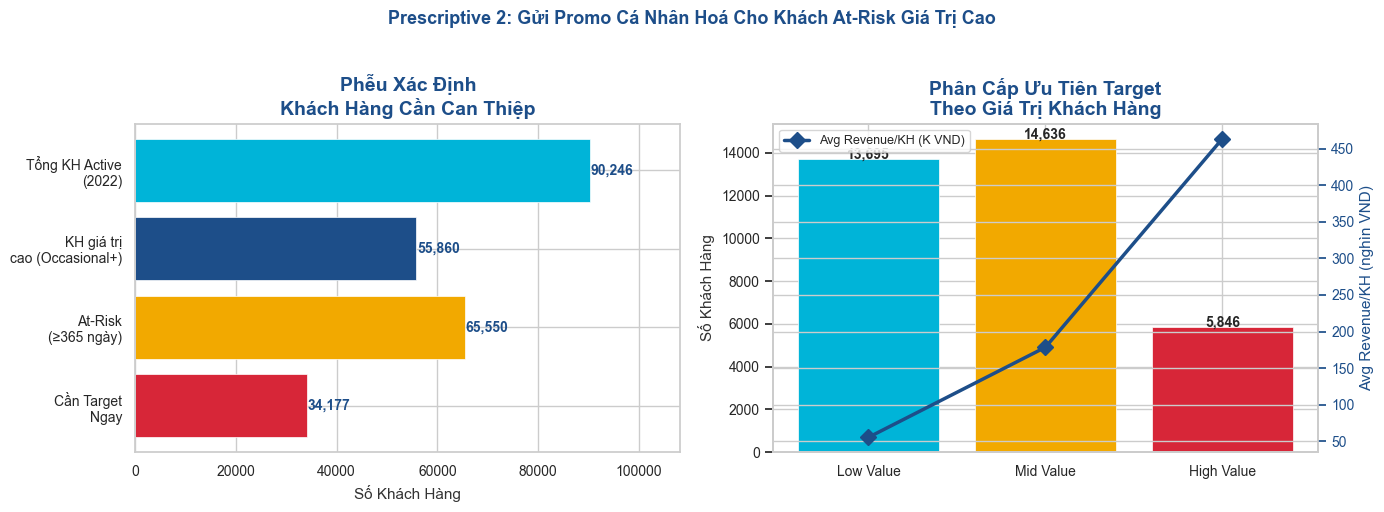

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Funnel KH cần target ---
ax = axes[0]
segments = ['Tổng KH Active\n(2022)', 'KH giá trị\ncao (Occasional+)',
            'At-Risk\n(≥365 ngày)', 'Cần Target\nNgay']
values   = [
    len(customer_last),
    len(customer_last[customer_last['dependency'].isin(['Occasional','Frequent'])]),
    len(customer_last[customer_last['is_at_risk']]),
    len(target)
]
colors_funnel = [C_INFO, C_PRIMARY, C_SECONDARY, C_ALERT]
bars = ax.barh(segments[::-1], values[::-1],
               color=colors_funnel[::-1], edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, values[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10, fontweight='bold', color=C_PRIMARY)
ax.set_xlabel('Số Khách Hàng')
ax.set_title('Phễu Xác Định\nKhách Hàng Cần Can Thiệp',
             fontweight='bold', color=C_PRIMARY)
ax.set_xlim(0, values[0] * 1.2)

# --- Plot 2: Priority breakdown ---
ax = axes[1]
p_colors = [C_INFO, C_SECONDARY, C_ALERT]
bars = ax.bar(priority_summary['priority'].astype(str),
              priority_summary['num_customers'],
              color=p_colors, edgecolor='white', linewidth=0.5)
ax2 = ax.twinx()
ax2.plot(range(len(priority_summary)),
         priority_summary['avg_revenue'] / 1e3,
         color=C_PRIMARY, linewidth=2.5, marker='D',
         markersize=8, label='Avg Revenue/KH (K VND)')
ax2.set_ylabel('Avg Revenue/KH (nghìn VND)', color=C_PRIMARY)
ax2.tick_params(axis='y', colors=C_PRIMARY)

for bar, val in zip(bars, priority_summary['num_customers']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 20, f'{val:,}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Số Khách Hàng')
ax.set_title('Phân Cấp Ưu Tiên Target\nTheo Giá Trị Khách Hàng',
             fontweight='bold', color=C_PRIMARY)
ax2.legend(fontsize=9, loc='upper left')

plt.suptitle(
    'Prescriptive 2: Gửi Promo Cá Nhân Hoá Cho Khách At-Risk Giá Trị Cao',
    fontsize=13, fontweight='bold', color=C_PRIMARY, y=1.02)
plt.tight_layout()
plt.savefig('pr2_target_customers.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()


Nhóm|	Điều kiện|	Số KH|	Ý nghĩa
---|---|---|---
Tổng KH Active|	Có ít nhất 1 đơn hàng trong dataset|	90,246|	Toàn bộ khách từng mua
KH Giá Trị Cao|	`promo_ratio` trong khoảng 0–80% → nhóm `Occasional` hoặc `Frequent`|	55,860|	Khách mua nhiều lần, không phụ thuộc hoàn toàn vào promo → có LTV cao
At-Risk	|`days_inactive` ≥ 365 — không mua trong vòng 1 năm tính từ ngày cuối dataset|	65,550	|Khách đang "ngủ đông", có nguy cơ churn vĩnh viễn
Cần Target Ngay|	Phải thỏa **đồng thời cả 2**: Giá Trị Cao VÀ At-Risk|	34,177|	Nhóm ưu tiên: đủ giá trị để đầu tư, đang có nguy cơ mất

**Phân Cấp Ưu Tiên**

| Nhóm | Số KH | Avg Revenue/KH | Tiềm Năng | Ưu Tiên |
|---|---|---|---|---|
| High Value | 5,846 (17%) | 464K VND | 2,710M VND | 🔴 **#1** |
| Mid Value | 14,636 (43%) | 178K VND | 2,612M VND | 🟡 **#2** |
| Low Value | 13,695 (40%) | 55K VND | 758M VND | 🟢 **#3** |

**Tổng doanh thu tiềm năng nếu giữ lại: 6,081M VND**

**Phát hiện nghiêm trọng — 72.6% khách active đã "ngủ đông":**

Hơn 2/3 khách hàng chưa mua trong 365+ ngày. Đây là
quy mô churn thực sự lớn hơn nhiều so với con số churn rate
hàng năm đã phân tích ở Q4.

**Chiến lược targeting đề xuất:**

| Nhóm | Loại promo | Thông điệp |
|---|---|---|
| High Value (5.8K) | Fixed discount 100–200K VND | "Ưu đãi đặc biệt dành riêng cho bạn" |
| Mid Value (14.6K) | Fixed discount 50–100K VND | "Chúng tôi nhớ bạn — quà tặng hồi quy" |
| Low Value (13.7K) | Không ưu tiên promo | Giữ cho email/remarketing thông thường |

> 💡 **Nếu giữ lại chỉ 20% High Value + Mid Value:**
> (5,846 + 14,636) × 20% × avg 300K ≈ **+1,229M VND**
> với chi phí targeting ~129M VND → **ROI ≈ 9.5x**

## Action 3: Mô phỏng tái phân bổ ngân sách

In [ ]:
# Ngân sách hiện tại
current_discount = oi_promo['discount_amount'].sum()

stop_budget   = promo_roi[promo_roi['recommendation']=='STOP']['total_discount'].sum()
review_budget = promo_roi[promo_roi['recommendation']=='REVIEW']['total_discount'].sum()
keep_budget   = promo_roi[promo_roi['recommendation']=='KEEP']['total_discount'].sum()

# Giả định: dùng 30% budget từ STOP để target at-risk customers
realloc_budget    = stop_budget * 0.30
saved_budget      = stop_budget * 0.70
target_cost_per_kh= realloc_budget / len(target) if len(target) > 0 else 0

# Ước tính recovery: nếu giữ lại 20% at-risk customers
recovery_rate      = 0.20
recovered_kh       = int(len(target) * recovery_rate)
avg_annual_revenue = target['total_revenue'].mean()
incremental_rev    = recovered_kh * avg_annual_revenue

print('=' * 62)
print('  SIMULATION: TÁI PHÂN BỔ NGÂN SÁCH PROMO')
print('=' * 62)
print(f'  Tổng discount hiện tại         : {current_discount/1e6:>8.1f}M VND')
print(f'  Budget nhóm STOP (tiết kiệm)   : {stop_budget/1e6:>8.1f}M VND')
print(f'  → Tiết kiệm thực               : {saved_budget/1e6:>8.1f}M VND (70%)')
print(f'  → Tái phân bổ cho targeting    : {realloc_budget/1e6:>8.1f}M VND (30%)')
print(f'  → Chi phí/KH được target       : {target_cost_per_kh:>8,.0f} VND')
print('-' * 62)
print(f'  KH at-risk được target         : {len(target):>8,}')
print(f'  Giả định giữ lại 20%           : {recovered_kh:>8,} KH')
print(f'  Avg revenue/KH giữ lại         : {avg_annual_revenue/1e3:>8.1f}K VND')
print(f'  → Incremental revenue ước tính : {incremental_rev/1e6:>8.1f}M VND')
print(f'  → Net benefit                  : {(incremental_rev+saved_budget)/1e6:>8.1f}M VND')
print('=' * 62)


  SIMULATION: TÁI PHÂN BỔ NGÂN SÁCH PROMO
  Tổng discount hiện tại         :    749.6M VND
  Budget nhóm STOP (tiết kiệm)   :    429.3M VND
  → Tiết kiệm thực               :    300.5M VND (70%)
  → Tái phân bổ cho targeting    :    128.8M VND (30%)
  → Chi phí/KH được target       :    3,768 VND
--------------------------------------------------------------
  KH at-risk được target         :   34,177
  Giả định giữ lại 20%           :    6,835 KH
  Avg revenue/KH giữ lại         :    177.9K VND
  → Incremental revenue ước tính :   1216.1M VND
  → Net benefit                  :   1516.6M VND


## Visual 3: Waterfall Chart — Budget Reallocation

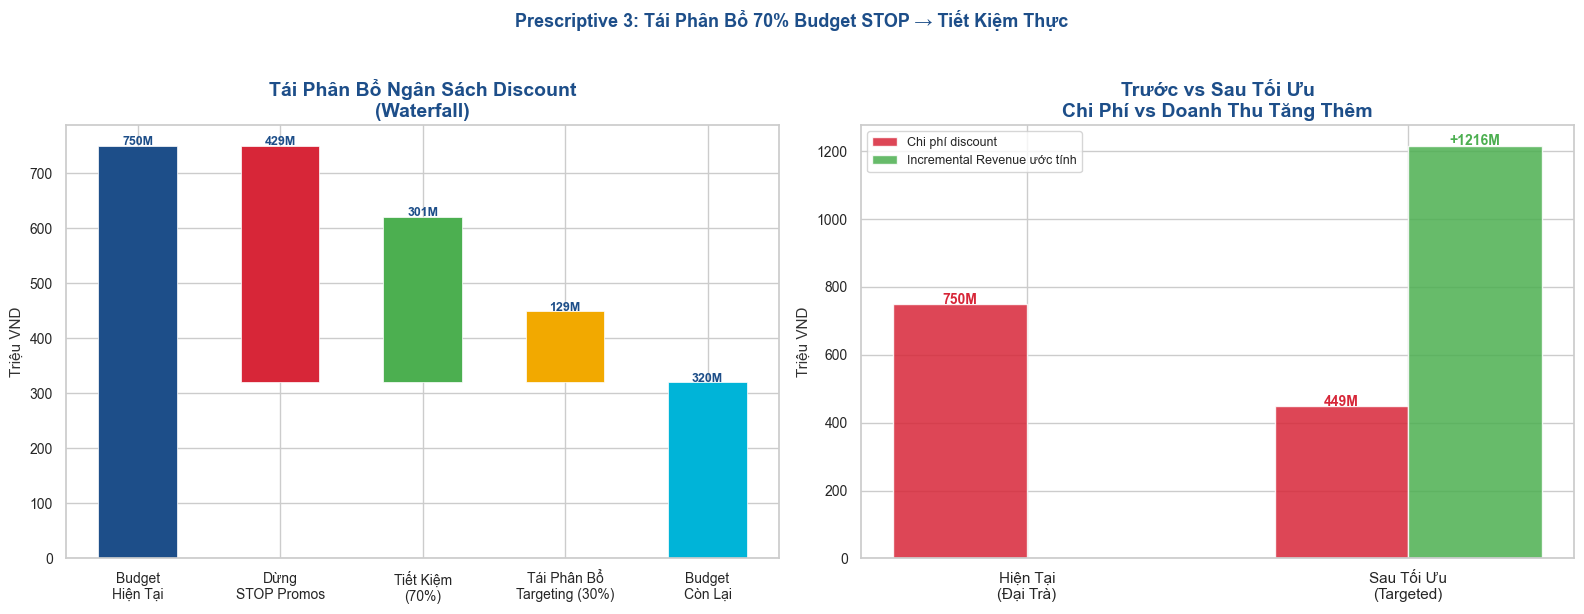

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Waterfall ngân sách ---
ax = axes[0]
categories = ['Budget\nHiện Tại', 'Dừng\nSTOP Promos',
              'Tiết Kiệm\n(70%)', 'Tái Phân Bổ\nTargeting (30%)',
              'Budget\nCòn Lại']
values_w   = [
    current_discount/1e6,
    -stop_budget/1e6,
    0,
    0,
    (current_discount - stop_budget)/1e6
]

running = current_discount/1e6
bottoms  = [0, running - stop_budget/1e6,
            running - stop_budget/1e6,
            running - stop_budget/1e6 - saved_budget/1e6,
            0]
heights  = [current_discount/1e6,
            stop_budget/1e6,
            saved_budget/1e6,
            realloc_budget/1e6,
            (current_discount - stop_budget)/1e6]
wf_colors= [C_PRIMARY, C_ALERT, C_SUCCESS, C_SECONDARY, C_INFO]

bars = ax.bar(categories, heights, bottom=[0,
              current_discount/1e6 - stop_budget/1e6,
              current_discount/1e6 - stop_budget/1e6,
              current_discount/1e6 - stop_budget/1e6,
              0],
              color=wf_colors, edgecolor='white', linewidth=0.5, width=0.55)

for bar, h, b in zip(bars, heights, [0,
        current_discount/1e6 - stop_budget/1e6,
        current_discount/1e6 - stop_budget/1e6,
        current_discount/1e6 - stop_budget/1e6, 0]):
    ax.text(bar.get_x() + bar.get_width()/2,
            b + h + 1, f'{h:.0f}M',
            ha='center', fontsize=9, fontweight='bold', color=C_PRIMARY)

ax.set_ylabel('Triệu VND')
ax.set_title('Tái Phân Bổ Ngân Sách Discount\n(Waterfall)',
             fontweight='bold', color=C_PRIMARY)

# --- Plot 2: Before vs After ---
ax = axes[1]
scenarios = ['Hiện Tại\n(Đại Trà)', 'Sau Tối Ưu\n(Targeted)']
costs      = [current_discount/1e6, (current_discount-saved_budget)/1e6]
rev_gain   = [0, incremental_rev/1e6]

x = np.arange(len(scenarios))
w = 0.35
ax.bar(x - w/2, costs, w, label='Chi phí discount',
       color=C_ALERT, alpha=0.85, edgecolor='white')
ax.bar(x + w/2, rev_gain, w, label='Incremental Revenue ước tính',
       color=C_SUCCESS, alpha=0.85, edgecolor='white')

for xi, c, r in zip(x, costs, rev_gain):
    ax.text(xi - w/2, c + 1, f'{c:.0f}M',
            ha='center', fontsize=10, fontweight='bold', color=C_ALERT)
    if r > 0:
        ax.text(xi + w/2, r + 1, f'+{r:.0f}M',
                ha='center', fontsize=10, fontweight='bold', color=C_SUCCESS)

ax.set_xticks(x)
ax.set_xticklabels(scenarios, fontsize=11)
ax.set_ylabel('Triệu VND')
ax.set_title('Trước vs Sau Tối Ưu\nChi Phí vs Doanh Thu Tăng Thêm',
             fontweight='bold', color=C_PRIMARY)
ax.legend(fontsize=9)

plt.suptitle(
    'Prescriptive 3: Tái Phân Bổ 70% Budget STOP → Tiết Kiệm Thực',
    fontsize=13, fontweight='bold', color=C_PRIMARY, y=1.02)
plt.tight_layout()
plt.savefig('pr3_budget_realloc.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()


```python
order_items.discount_amount
        │ sum theo promo_id
        ↓
promo_roi['total_discount']   +   roi, discount_depth
        │ classify → STOP / REVIEW / KEEP
        ↓
STOP budget = 429 M ──────────────────────────────┐
        │                                         │
        ├─ × 70% → 301 M TIẾT KIỆM THỰC           │
        │                                         │
        └─ × 30% → 129 M TÁI PHÂN BỔ              │
                │                                 │
                ÷ 34,177 KH target                │
                │                                 │
                = 3,768 VND/KH                    │
                                                  │
target group (at-risk + high value)               │
        │ × 20% recovery (giả định)               │
        │ × 177.9 K avg revenue                   │
        ↓                                         │
  +1,216 M Incremental Revenue                    │
        │                                         │
        + ←───────────────────────────────────────┘
        ↓
  NET BENEFIT = 1,517 M VND

```

Prescriptive 3 — Mô Phỏng Tái Phân Bổ Ngân Sách

### Kết Quả Simulation

| Chỉ số | Hiện Tại | Sau Tối Ưu |
|---|---|---|
| Tổng chi phí discount | 750M VND | **449M VND (-40%)** |
| Incremental revenue | 0 | **+1,216M VND** |
| Cost/KH targeted | — | **3,768 VND** |
| Net benefit | — | **+1,517M VND** |



**ROI So Sánh**

| Chiến lược | ROI |
|---|---|
| Percentage promo hiện tại | 5.79x |
| **Targeted promo mới** | **9.4x (+62%)** |

> ⚠️ **Giả định cần kiểm chứng:**
> Recovery rate 20% là ước tính thận trọng.
> Cần A/B test thực tế để xác nhận trước khi
> triển khai toàn bộ ngân sách 129M VND.
>
> 💡 **Đề xuất:** Bắt đầu với 5,846 KH **High Value**
> — nếu recovery rate đạt 20%, incremental revenue
> chỉ từ nhóm này ≈ **542M VND** với chi phí ~22M VND.

## TỔNG KẾT Bước 4: Prescriptive Analysis

**Bối Cảnh Ra Quyết Định**

Dựa trên 3 bước phân tích trước:
- **Descriptive:** 38.37% đơn dùng promo nhưng chỉ tạo 29.9% doanh thu
- **Diagnostic:** Promo không tạo incremental revenue (r = -0.278), ROI thấp, nhắm sai category
- **Predictive:** Doanh thu giảm thêm 32%, churn rate tăng lên 66.7% vào 2025 nếu không can thiệp

3 Hành Động Cụ Thể

---
### ACTION 1 — Dừng Mã Promo ROI Thấp
**Cơ sở:** Ma trận ROI phân loại 50 mã promo → nhóm STOP có ROI < 5x,
Discount Depth ~18–20%, chiếm **57.3% tổng ngân sách (429M VND)**
| Nhóm | Số mã | Budget | ROI trung bình |
|---|---|---|---|
| 🟢 KEEP | ít | 5M VND (0.6%) | > 8x |
| 🟡 REVIEW | vừa | 316M VND (42.1%) | 5–8x |
| 🔴 **STOP** | nhiều | **429M VND (57.3%)** | **< 5x** |

**Hành động:** Dừng toàn bộ mã thuộc nhóm STOP.
Ưu tiên dừng trước: Year-End Sale 20% — tốn kém nhất, ROI thấp nhất.

**Tiết kiệm trực tiếp: 429M VND/kỳ promo**

---
### ACTION 2 — Gửi Promo Cá Nhân Hoá Cho Khách At-Risk Giá Trị Cao
**Cơ sở:** 34,177 khách vừa có giá trị cao (Occasional/Frequent),
vừa không mua trong ≥ 365 ngày — đây là nhóm **sắp mất vĩnh viễn**.

| Nhóm Ưu Tiên | Số KH | Avg Revenue/KH | Loại Promo Đề Xuất |
|---|---|---|---|
| 🔴 High Value | 5,846 | 464K VND | Fixed 100–200K VND + thông điệp cá nhân |
| 🟡 Mid Value | 14,636 | 178K VND | Fixed 50–100K VND + "chúng tôi nhớ bạn" |
| 🟢 Low Value | 13,695 | 55K VND | Không ưu tiên — chỉ email thông thường |

**Tổng tiềm năng nếu giữ lại:** 6,081M VND

**Cost per KH targeted:** chỉ 3,768 VND

---
### ACTION 3 — Tái Phân Bổ Ngân Sách: 70% Tiết Kiệm / 30% Targeting
**Cơ sở:** Dùng budget từ ACTION 1 để tài trợ ACTION 2

```python
429 M (STOP budget)
├─ 70% = 301 M VND → TIẾT KIỆM THỰC
└─ 30% = 129 M VND → TÁI PHÂN BỔ CHO TARGETING
```

**Kết quả simulation:**
| Chỉ số | Hiện Tại | Sau Tối Ưu |
|---|---|---|
| Tổng chi phí discount | 750M VND | **449M VND (-40%)** |
| Incremental Revenue | 0 | **+1,216M VND** |
| ROI chiến lược | 5.79x | **9.4x (+62%)** |
| **Net Benefit** | — | **+1,517M VND** |